# Análise Exploratória de Dados

**Projeto:** ANEEL - Energia em Risco: Análise de Dados de Continuidade Elétrica e Previsão de Risco Regulatório

**Metodologia:** CRISP-DM 

**Período de Análise:** 2021 – 2025

---

## Visão Geral

Este notebook consolida a **Fase 2 do CRISP-DM - Compreensão dos Dados (Data Understanding)**. O objetivo é compreender o comportamento histórico dos indicadores DEC/FEC e das interrupções, explorando distribuições, tendências temporais, diferenças entre distribuidoras e regiões, outliers e relações relevantes para a modelagem preditiva.

---


## Sumário

1. Configurações do ambiente  
2. Inventário das tabelas analíticas  
3. Perfil dos dados  
4. Distribuição dos indicadores DEC e FEC  
5. Evolução temporal  
6. Comparação por distribuidora e região 
7. Análise das interrupções  
8. Análise de outliers
9. Relações entre variáveis 
10. Perguntas de Partida, Hipóteses e Insights
11. Síntese exploratória

---

## 1. Configurações do ambiente

In [240]:
# Importações
import sys
import os
from pathlib import Path

import duckdb
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from IPython.display import display, Image, Markdown

# Configurações de diretórios
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DIR
from src.data.constants import ANO_INICIO, ANO_FIM

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
METADATA_DIR = PROJECT_ROOT / "docs" / "metadata"

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(METADATA_DIR, exist_ok=True)

# Configurações de visualização
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", lambda value: f"{value:.2f}")
sns.set_theme(style="whitegrid")

# Conexão DuckDB
con = duckdb.connect()

# Tabelas Gold utilizadas na análise exploratória
FACT_CONT_PATH = PROCESSED_DIR / "fato_continuidade.parquet"
FACT_CAUSA_PATH = PROCESSED_DIR / "fato_causa_mensal.parquet"
DIM_DATA_PATH = PROCESSED_DIR / "dim_data.parquet"
DIM_DISTRIBUIDORA_PATH = PROCESSED_DIR / "dim_distribuidora.parquet"
DIM_CONJUNTO_PATH = PROCESSED_DIR / "dim_conjunto.parquet"
DIM_INDICADOR_PATH = PROCESSED_DIR / "dim_indicador.parquet"
DIM_TIPO_PATH = PROCESSED_DIR / "dim_tipo_interrupcao.parquet"
DIM_MOTIVO_PATH = PROCESSED_DIR / "dim_motivo_interrupcao.parquet"
DIM_CAUSA_PATH = PROCESSED_DIR / "dim_causa_interrupcao.parquet"

required_paths = [
    FACT_CONT_PATH, FACT_CAUSA_PATH, DIM_DATA_PATH, DIM_DISTRIBUIDORA_PATH,
    DIM_CONJUNTO_PATH, DIM_INDICADOR_PATH, DIM_TIPO_PATH, DIM_MOTIVO_PATH,
    DIM_CAUSA_PATH,
]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError("Arquivos processed ausentes:\n" + "\n".join(missing_paths))

print(f"Período analisado: {ANO_INICIO}-{ANO_FIM}")

Período analisado: 2021-2025


In [241]:
#Definindo a paleta de cores
colors = ["#959300","#01719f","#004e72"]
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette(colors))


---

## 2. Inventário das tabelas analíticas


A análise exploratória utiliza as tabelas da camada `processed`, organizadas no Star Schema. As tabelas fato concentram as métricas; as dimensões fornecem os contextos temporal, cadastral, geográfico e regulatório.

In [242]:
# Inventário das tabelas analíticas utilizadas na EDA
ANALYTICAL_TABLES = {
    "fato_continuidade": (FACT_CONT_PATH, "Fato", "Indicadores DEC/FEC, limites e transgressões"),
    "fato_causa_mensal": (FACT_CAUSA_PATH, "Fato", "Interrupções agregadas e contribuições estimadas"),
    "dim_data": (DIM_DATA_PATH, "Dimensão", "Calendário e atributos temporais"),
    "dim_distribuidora": (DIM_DISTRIBUIDORA_PATH, "Dimensão", "Distribuidoras e identificadores"),
    "dim_conjunto": (DIM_CONJUNTO_PATH, "Dimensão", "Conjuntos, localização e cadastro"),
    "dim_indicador": (DIM_INDICADOR_PATH, "Dimensão", "Indicadores DEC e FEC"),
    "dim_tipo_interrupcao": (DIM_TIPO_PATH, "Dimensão", "Tipos de interrupção"),
    "dim_motivo_interrupcao": (DIM_MOTIVO_PATH, "Dimensão", "Motivos regulatórios"),
    "dim_causa_interrupcao": (DIM_CAUSA_PATH, "Dimensão", "Causas normalizadas"),
}

inventory_rows = []
for table_name, (table_path, table_type, purpose) in ANALYTICAL_TABLES.items():
    schema = con.execute("DESCRIBE SELECT * FROM read_parquet(?)", [str(table_path)]).fetchall()
    row_count = int(con.execute("SELECT COUNT(*) FROM read_parquet(?)", [str(table_path)]).fetchone()[0])
    inventory_rows.append({
        "tabela": table_name,
        "tipo": table_type,
        "linhas": row_count,
        "colunas": len(schema),
        "finalidade": purpose,
    })

df_analytical_inventory = pd.DataFrame(inventory_rows)
display(df_analytical_inventory)

,tabela,tipo,linhas,colunas,finalidade
0,fato_continuidade,Fato,375082,10,"Indicadores DEC/FEC, limites e transgressões"
1,fato_causa_mensal,Fato,3002279,16,Interrupções agregadas e contribuições estimadas
2,dim_data,Dimensão,1826,7,Calendário e atributos temporais
3,dim_distribuidora,Dimensão,105,3,Distribuidoras e identificadores
4,dim_conjunto,Dimensão,3824,9,"Conjuntos, localização e cadastro"
5,dim_indicador,Dimensão,2,4,Indicadores DEC e FEC
6,dim_tipo_interrupcao,Dimensão,2,2,Tipos de interrupção
7,dim_motivo_interrupcao,Dimensão,9,4,Motivos regulatórios
8,dim_causa_interrupcao,Dimensão,518,5,Causas normalizadas


---

## 3. Perfil dos dados

Esta seção resume a completude, os tipos numéricos e as principais métricas das tabelas fato e dimensão. As consultas são executadas no DuckDB para preservar o desempenho sobre os arquivos Parquet.

### 3.1. Completude das tabelas fato

In [243]:
# Perfil de completude das tabelas fato

full_table_path = os.path.join(METADATA_DIR, "fact_profile.csv")
relative_table_path = os.path.relpath(full_table_path)

fact_profiles = []
for table_name, table_path in {
    "fato_continuidade": FACT_CONT_PATH,
    "fato_causa_mensal": FACT_CAUSA_PATH,
}.items():
    total_rows = int(
        con.execute(
            "SELECT COUNT(*) FROM read_parquet(?)", [str(table_path)]
        ).fetchone()[0]
    )
    schema = con.execute(
        "DESCRIBE SELECT * FROM read_parquet(?)", [str(table_path)]
    ).fetchall()
    for column_name, data_type, *_ in schema:
        null_count = int(
            con.execute(
                f'SELECT COUNT(*) FILTER (WHERE "{column_name}" IS NULL) FROM read_parquet(?)',
                [str(table_path)],
            ).fetchone()[0]
        )
        fact_profiles.append(
            {
                "tabela": table_name,
                "coluna": column_name,
                "tipo": data_type,
                "linhas": total_rows,
                "nulos": null_count,
                "percentual_nulos": (
                    round(null_count / total_rows * 100, 2) if total_rows else 0
                ),
            }
        )

df_fact_profile = pd.DataFrame(fact_profiles)
display(df_fact_profile.style.format({"percentual_nulos": "{:.2f}%"}))

df_fact_profile.to_csv(
    full_table_path,
    index=False,
)

print(f"Tabela salva com sucesso em: {relative_table_path}")

,tabela,coluna,tipo,linhas,nulos,percentual_nulos
0,fato_continuidade,FatoContinuidadeKey,UBIGINT,375082,0,0.00%
1,fato_continuidade,DataKey,INTEGER,375082,0,0.00%
2,fato_continuidade,DistribuidoraKey,BIGINT,375082,0,0.00%
3,fato_continuidade,ConjuntoKey,BIGINT,375082,0,0.00%
4,fato_continuidade,IndicadorKey,TINYINT,375082,0,0.00%
5,fato_continuidade,VlrIndicador,DOUBLE,375082,0,0.00%
6,fato_continuidade,VlrLimite,DOUBLE,375082,754,0.20%
7,fato_continuidade,UltrapassouLimite,TINYINT,375082,0,0.00%
8,fato_continuidade,ExcessoSobreLimite,DOUBLE,375082,0,0.00%
9,fato_continuidade,PercentualDoLimite,DOUBLE,375082,754,0.20%


Tabela salva com sucesso em: ..\docs\metadata\fact_profile.csv


### 3.2. Completude das dimensões

In [244]:
# Perfil de completude das tabelas dimensão

full_table_path = os.path.join(METADATA_DIR, "dimension_profile.csv")
relative_table_path = os.path.relpath(full_table_path)

dimension_profiles = []
for table_name, (table_path, _, _) in ANALYTICAL_TABLES.items():
    if not table_name.startswith("dim_"):
        continue
    total_rows = int(
        con.execute(
            "SELECT COUNT(*) FROM read_parquet(?)", [str(table_path)]
        ).fetchone()[0]
    )
    schema = con.execute(
        "DESCRIBE SELECT * FROM read_parquet(?)", [str(table_path)]
    ).fetchall()
    for column_name, data_type, *_ in schema:
        null_count = int(
            con.execute(
                f'SELECT COUNT(*) FILTER (WHERE "{column_name}" IS NULL) FROM read_parquet(?)',
                [str(table_path)],
            ).fetchone()[0]
        )
        dimension_profiles.append(
            {
                "tabela": table_name,
                "coluna": column_name,
                "tipo": data_type,
                "linhas": total_rows,
                "nulos": null_count,
                "percentual_nulos": (
                    round(null_count / total_rows * 100, 2) if total_rows else 0
                ),
            }
        )

df_dimension_profile = pd.DataFrame(dimension_profiles)
display(df_dimension_profile.style.format({"percentual_nulos": "{:.2f}%"}))

df_dimension_profile.to_csv(
    full_table_path,
    index=False,
)

print(f"Tabela salva com sucesso em: {relative_table_path}")

,tabela,coluna,tipo,linhas,nulos,percentual_nulos
0,dim_data,DataKey,INTEGER,1826,0,0.00%
1,dim_data,Data,DATE,1826,0,0.00%
2,dim_data,Ano,SMALLINT,1826,0,0.00%
3,dim_data,MesNumero,TINYINT,1826,0,0.00%
4,dim_data,MesNome,VARCHAR,1826,0,0.00%
5,dim_data,AnoMes,VARCHAR,1826,0,0.00%
6,dim_data,Trimestre,VARCHAR,1826,0,0.00%
7,dim_distribuidora,SigAgente,VARCHAR,105,0,0.00%
8,dim_distribuidora,NumCNPJ,VARCHAR,105,0,0.00%
9,dim_distribuidora,DistribuidoraKey,BIGINT,105,0,0.00%


Tabela salva com sucesso em: ..\docs\metadata\dimension_profile.csv


- As tabelas fato apresentam alta completude: os campos de identificação e as métricas operacionais da fato de interrupções não possuem nulos nas verificações realizadas.

- As colunas `VlrLimite` e `PercentualDoLimite` apresentam uma pequena quantidade de valores ausentes na fato de continuidade, sendo coerente com as combinações sem limite regulatório identificadas no notebook de auditoria de qualidade.

- As tabelas dimensões apresentam `0,00%` de nulos nas colunas avaliadas, preservando o contexto temporal, cadastral, geográfico e regulatório dos fatos.

---

## 4. Distribuição dos indicadores DEC e FEC

A análise compara a distribuição dos valores apurados, seus limites regulatórios e a ocorrência de ultrapassagens para os indicadores DEC e FEC.

### 4.1. Estatísticas por indicador

In [245]:
# Estatísticas descritivas das principais métricas das tabelas fato
metric_queries = {
    "fato_continuidade": (FACT_CONT_PATH, ["VlrIndicador", "VlrLimite", "ExcessoSobreLimite", "PercentualDoLimite"]),
    "fato_causa_mensal": (FACT_CAUSA_PATH, ["QtdInterrupcoes", "DuracaoTotalHoras", "DuracaoMediaHoras", "MaiorInterrupcaoHoras", "UnidadesAfetadasSoma", "ConsumidorHoras"]),
}

profile_rows = []
for table_name, (table_path, columns) in metric_queries.items():
    for column_name in columns:
        stats = con.execute(f"""
            SELECT
                MIN("{column_name}"),
                QUANTILE_CONT("{column_name}", 0.25),
                MEDIAN("{column_name}"),
                QUANTILE_CONT("{column_name}", 0.75),
                MAX("{column_name}")
            FROM read_parquet(?)
        """, [str(table_path)]).fetchone()
        profile_rows.append({
            "tabela": table_name,
            "metrica": column_name,
            "minimo": stats[0],
            "q1": stats[1],
            "mediana": stats[2],
            "q3": stats[3],
            "maximo": stats[4],
        })

df_metric_profile = pd.DataFrame(profile_rows)
display(df_metric_profile.style.format({
    "minimo": "{:.2f}", "q1": "{:.2f}", "mediana": "{:.2f}", "q3": "{:.2f}", "maximo": "{:.2f}"
}))

,tabela,metrica,minimo,q1,mediana,q3,maximo
0,fato_continuidade,VlrIndicador,0.00,0.25,0.48,0.95,56.35
1,fato_continuidade,VlrLimite,1.00,6.00,8.00,13.00,201.00
2,fato_continuidade,ExcessoSobreLimite,0.00,0.00,0.00,0.00,23.04
3,fato_continuidade,PercentualDoLimite,0.00,0.03,0.05,0.09,4.22
4,fato_causa_mensal,QtdInterrupcoes,1.00,2.00,4.00,12.00,1972.00
5,fato_causa_mensal,DuracaoTotalHoras,0.00,5.47,20.13,70.73,114175.95
6,fato_causa_mensal,DuracaoMediaHoras,0.00,2.42,4.23,7.65,4383.56
7,fato_causa_mensal,MaiorInterrupcaoHoras,0.00,3.62,7.90,21.22,8779.83
8,fato_causa_mensal,UnidadesAfetadasSoma,0.00,9.00,130.00,756.00,665619.00
9,fato_causa_mensal,ConsumidorHoras,0.00,40.05,376.35,1879.69,7591387.88


### 4.2. Distribuição dos indicadores

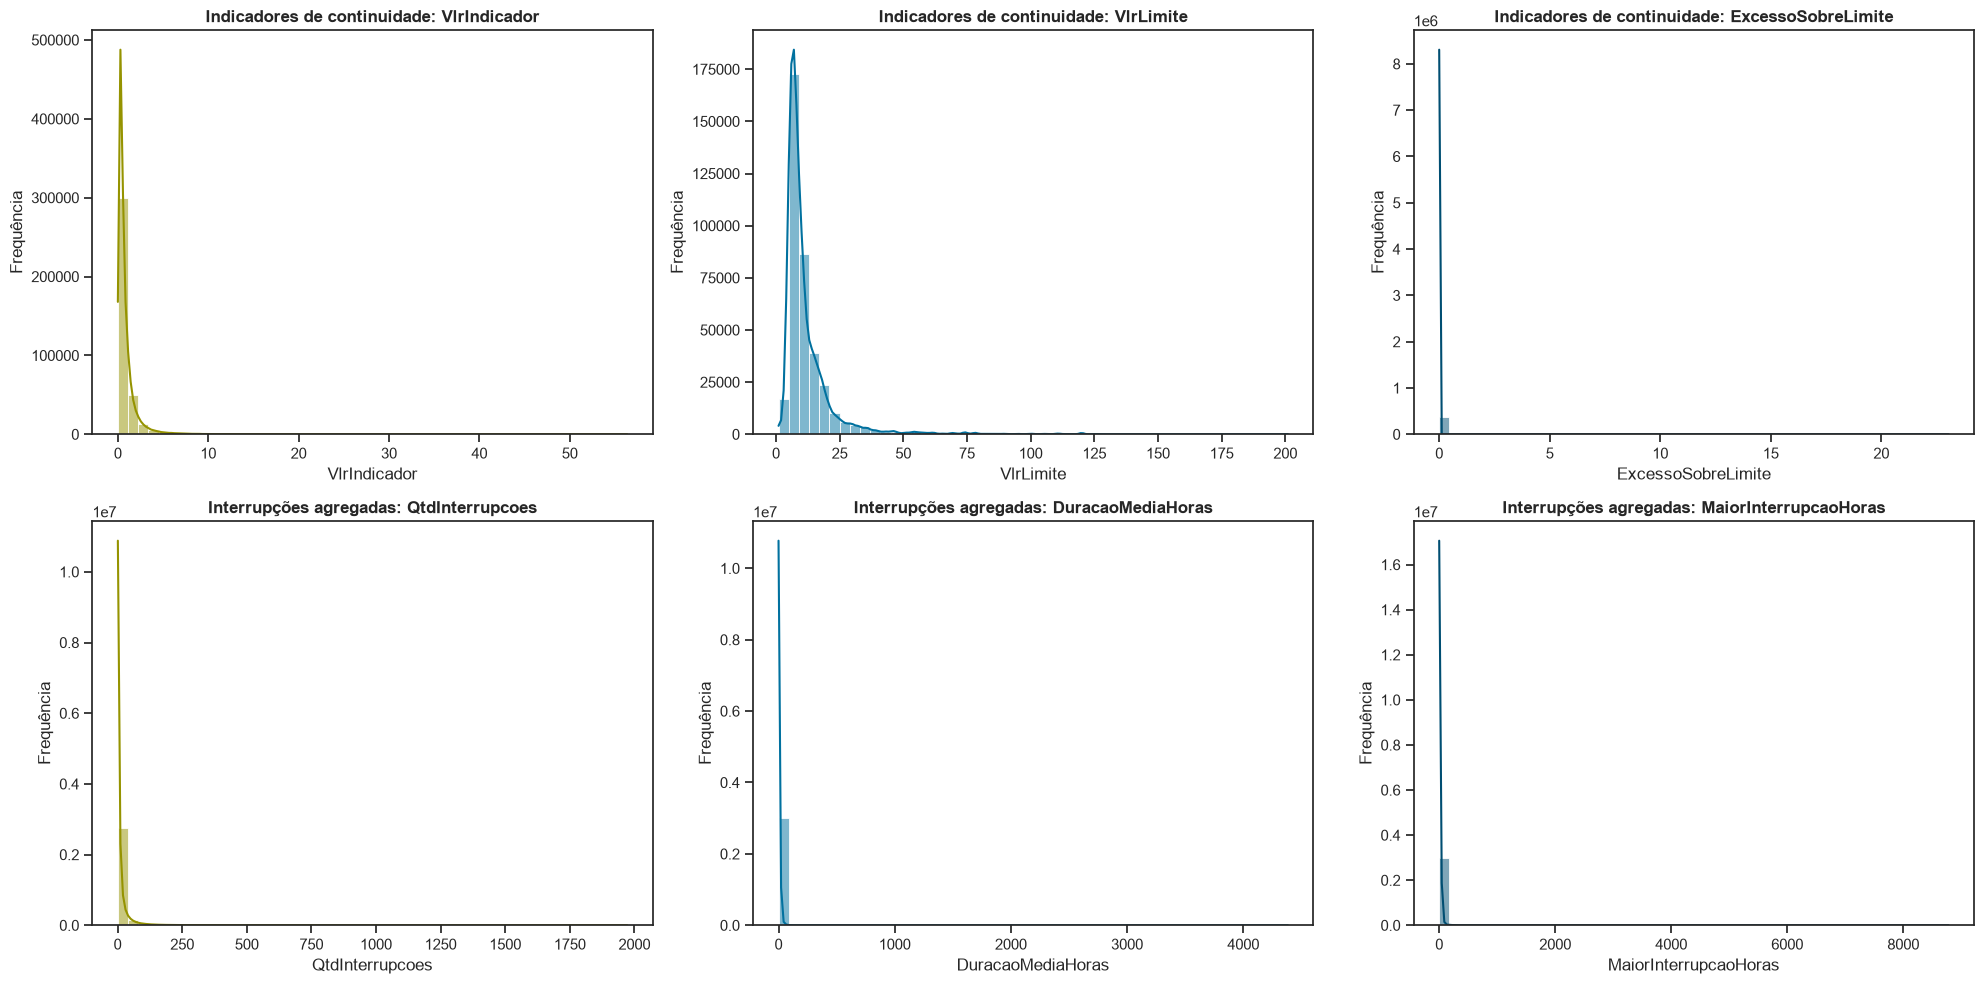

Gráfico salvo com sucesso em: ..\reports\figures\histogram_indicators.png


In [246]:
# Histogramas das principais métricas para avaliar distribuição e potenciais outliers

full_image_path = os.path.join(FIGURES_DIR, "histogram_indicators.png")
relative_image_path = os.path.relpath(full_image_path)

histogram_specs = [
    (
        FACT_CONT_PATH,
        ["VlrIndicador", "VlrLimite", "ExcessoSobreLimite"],
        "Indicadores de continuidade",
    ),
    (
        FACT_CAUSA_PATH,
        ["QtdInterrupcoes", "DuracaoMediaHoras", "MaiorInterrupcaoHoras"],
        "Interrupções agregadas",
    ),
]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for row_index, (table_path, columns, title) in enumerate(histogram_specs):
    quoted_columns = ", ".join(f'"{column}"' for column in columns)
    data = con.execute(
        f"SELECT {quoted_columns} FROM read_parquet(?)",
        [str(table_path)],
    ).df()
    for column_index, column_name in enumerate(columns):
        axis = axes[row_index, column_index]
        sns.histplot(
            data[column_name].dropna(),
            bins=50,
            kde=True,
            color=colors[column_index],
            ax=axis,
        )
        axis.set_title(f"{title}: {column_name}", fontweight="bold")
        axis.set_xlabel(column_name)
        axis.set_ylabel("Frequência")

plt.tight_layout()
plt.savefig(relative_image_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo com sucesso em: {relative_image_path}")


- Mais de `75%` dos registros da coluna `ExcessoSobreLimite` operam dentro da conformidade regulatória.

- Todas as distribuições são assimétricas à direita, com maior concentração de eventos próximos a zero e cauda longa à direita.

- Os histogramas evidenciam valores extremos em indicadores de continuidade, quantidade de interrupções e duração dos eventos agregados.

- Os valores centrais do serviço são aparentemente estáveis, com mediana de `4` interrupções mensais por causa, com duração média de `4,23h` e mediana de `130` clientes afetados, evidenciando que o risco de descumprimento de metas e o passivo operacional estão concentrados num grupo restrito de conjuntos elétricos críticos.


---

## 5. Evolução temporal

A evolução temporal permite observar como os indicadores DEC/FEC e a taxa de ultrapassagem dos limites se comportam ao longo dos meses e anos analisados.

In [247]:
# Evolução mensal dos indicadores e das ultrapassagens
query_timeline = f"""
SELECT
    d.AnoMes,
    d.Ano,
    d.MesNumero,
    i.SigIndicador,
    COUNT(*) AS observacoes,
    ROUND(AVG(f.VlrIndicador), 2) AS media_apurada,
    ROUND(AVG(f.VlrLimite), 2) AS media_limite,
    ROUND(100.0 * AVG(f.UltrapassouLimite), 2) AS percentual_ultrapassagem
FROM read_parquet('{FACT_CONT_PATH}') f
JOIN read_parquet('{DIM_DATA_PATH}') d
  ON f.DataKey = d.DataKey
JOIN read_parquet('{DIM_INDICADOR_PATH}') i
  ON f.IndicadorKey = i.IndicadorKey
GROUP BY d.AnoMes, d.Ano, d.MesNumero, i.SigIndicador
ORDER BY d.Ano, d.MesNumero, i.SigIndicador
"""

df_timeline = con.execute(query_timeline).df()
display(df_timeline)

,AnoMes,Ano,MesNumero,SigIndicador,observacoes,media_apurada,media_limite,percentual_ultrapassagem
0,2021-01,2021,1,DEC,3116,1.66,14.38,0.19
1,2021-01,2021,1,FEC,3116,0.70,10.05,0.00
2,2021-02,2021,2,DEC,3116,1.41,14.38,0.06
3,2021-02,2021,2,FEC,3116,0.62,10.05,0.00
4,2021-03,2021,3,DEC,3117,1.50,14.38,0.03
...,...,...,...,...,...,...,...,...
115,2025-10,2025,10,FEC,3149,0.48,8.77,0.00
116,2025-11,2025,11,DEC,3150,0.99,13.30,0.03
117,2025-11,2025,11,FEC,3150,0.45,8.77,0.03
118,2025-12,2025,12,DEC,3150,1.16,13.30,0.03


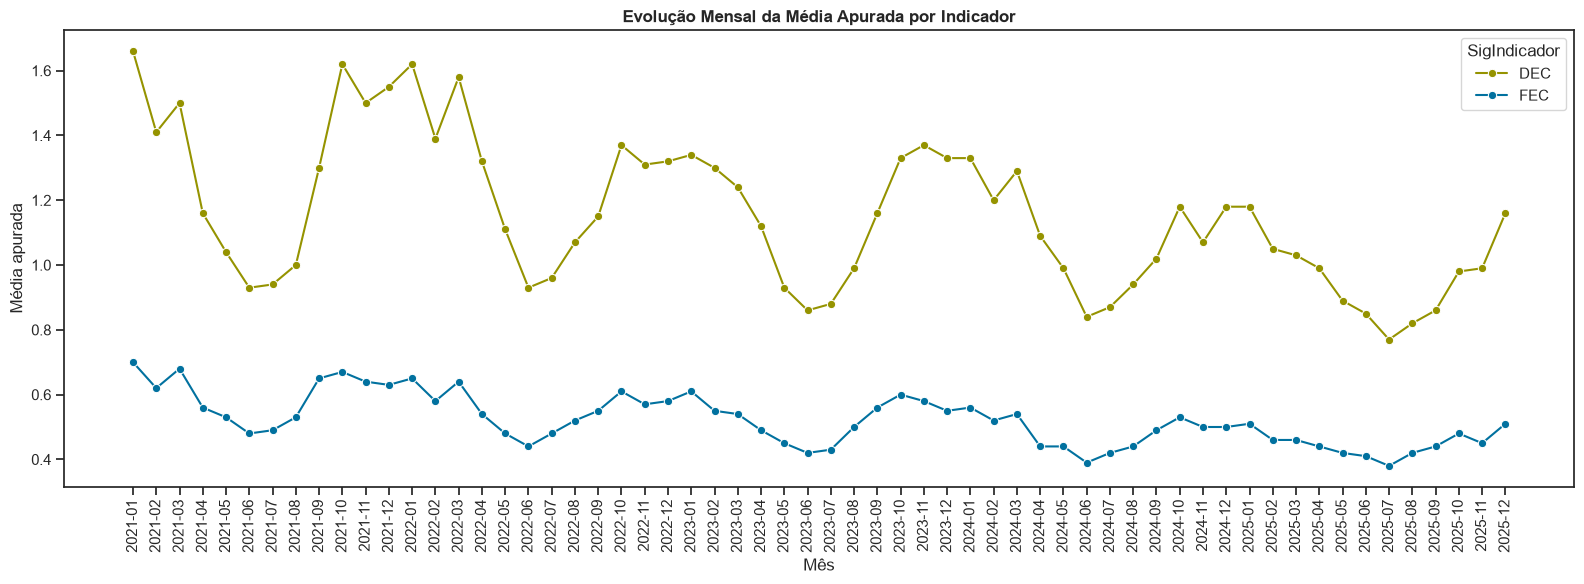

Gráfico salvo com sucesso em: ..\reports\figures\monthly_mean_evolution_indicators.png


In [248]:
# Gráfico de linha da média apurada de DEC e FEC
full_image_path = os.path.join(FIGURES_DIR, "monthly_mean_evolution_indicators.png")
relative_image_path = os.path.relpath(full_image_path)

plt.figure(figsize=(16, 6))
sns.lineplot(
    data=df_temporal,
    x="AnoMes",
    y="media_apurada",
    hue="SigIndicador",
    marker="o",
    palette=colors[:2],
)
plt.title("Evolução Mensal da Média Apurada por Indicador", fontweight="bold")
plt.xlabel("Mês")
plt.ylabel("Média apurada")
plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig(relative_image_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo com sucesso em: {relative_image_path}")

- O DEC oscila em patamares médios bem mais elevados (variando entre ~0,8 e ~1,65) em relação ao FEC (que varia entre ~0,4 e ~0,7), indicando que a duração acumulada é operacionalmente mais volátil que a quantidade de quedas.

- Ambos os indicadores apresentam ciclos anuais bem definidos, com vales acentuados no meio do ano (junho a agosto, quando o DEC atinge mínimas próximas a 0,8) e elevações consistentes entre o fim da primavera e o verão no hemisfério sul (outubro a março, com picos de DEC entre 1,3 e mais de 1,6).

- Observa-se uma trajetória decrescente de longo prazo de 2021 a 2025 tanto no DEC (cujos picos caíram de 1,65 em 2021 para aproximadamente 1,2 em 2024/2025) quanto no FEC (que recuou de 0,7 para a faixa de 0,4 a 0,5).

- Os picos e vales sugerem um comportamento sazonal ou influência de eventos operacionais, que pode ser investigada por mês, região e distribuidora.

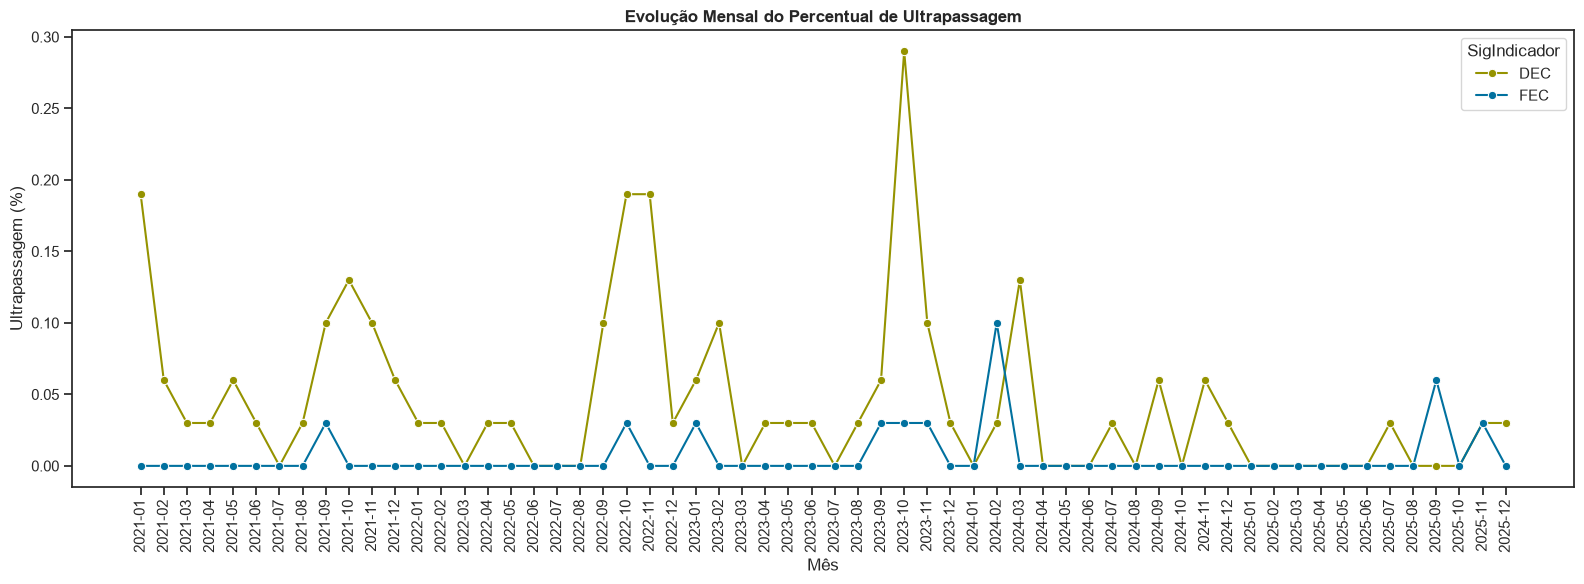

Gráfico salvo com sucesso em: ..\reports\figures\monthly_mean_evolution_overtaking.png


In [249]:
# Gráfico de linha do percentual de ultrapassagem
full_image_path = os.path.join(FIGURES_DIR, "monthly_mean_evolution_overtaking.png")
relative_image_path = os.path.relpath(full_image_path)

plt.figure(figsize=(16, 6))
sns.lineplot(
    data=df_temporal,
    x="AnoMes",
    y="percentual_ultrapassagem",
    hue="SigIndicador",
    marker="o",
    palette=colors[:2],
)
plt.title("Evolução Mensal do Percentual de Ultrapassagem", fontweight="bold")
plt.xlabel("Mês")
plt.ylabel("Ultrapassagem (%)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig(relative_image_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo com sucesso em: {relative_image_path}")

- A violação das metas regulatórias é fortemente concentrada no DEC, que apresenta índices frequentes de ultrapassagem (com picos repetidos próximos a `19%` e um ápice atípico de quase `30%` em outubro de 2023).

- O FEC mantém taxa de ultrapassagem nula (`0,00%`) na quase totalidade dos meses analisados, registrando apenas elevações pontuais e isoladas (como o pico de `10%` no início de 2024 e `~6%` no fim de 2025).

- Os maiores percentuais de ultrapassagem de DEC alinham-se aos meses de piora da média apurada (especialmente a janela de outubro a janeiro).

---

## 6. Comparação por distribuidora e região



Esta seção compara a continuidade do serviço entre distribuidoras e regiões, considerando volume de observações, média apurada e percentual de ultrapassagem. As comparações consideram diferenças de cobertura e quantidade de conjuntos por grupo.

In [250]:
# Comparação por distribuidora e região
query_distributor_region = f"""
SELECT
    d.SigAgente,
    c.Regiao,
    i.SigIndicador,
    COUNT(*) AS observacoes,
    COUNT(DISTINCT f.ConjuntoKey) AS conjuntos,
    ROUND(AVG(f.VlrIndicador), 2) AS media_apurada,
    ROUND(AVG(f.VlrLimite), 2) AS media_limite,
    ROUND(100.0 * AVG(f.UltrapassouLimite), 2) AS percentual_ultrapassagem
FROM read_parquet('{FACT_CONT_PATH}') f
JOIN read_parquet('{DIM_DISTRIBUIDORA_PATH}') d
  ON f.DistribuidoraKey = d.DistribuidoraKey
JOIN read_parquet('{DIM_CONJUNTO_PATH}') c
  ON f.ConjuntoKey = c.ConjuntoKey
JOIN read_parquet('{DIM_INDICADOR_PATH}') i
  ON f.IndicadorKey = i.IndicadorKey
GROUP BY d.SigAgente, c.Regiao, i.SigIndicador
ORDER BY percentual_ultrapassagem DESC, observacoes DESC
"""

df_distributor_region = con.execute(query_distributor_region).df()
display(df_distributor_region.head(10))

,SigAgente,Regiao,SigIndicador,observacoes,conjuntos,media_apurada,media_limite,percentual_ultrapassagem
0,EQUATORIAL GO,CENTRO-OESTE,DEC,9144,175,2.33,13.74,0.45
1,CEEE-D,SUL,DEC,3708,95,1.65,9.43,0.22
2,LIGHT SESA,SUDESTE,FEC,6492,114,0.30,4.87,0.11
3,EQUATORIAL PA,NORTE,DEC,8796,171,2.17,30.80,0.08
4,LIGHT SESA,SUDESTE,DEC,6492,114,0.63,7.14,0.08
5,CPFL JAGUARI,SUDESTE,DEC,1380,39,0.42,7.95,0.07
6,ELETROPAULO,SUDESTE,DEC,8580,145,0.56,6.81,0.06
7,CELESC,SUL,DEC,7404,166,0.86,11.47,0.05
8,EQUATORIAL MA,NORDESTE,DEC,5844,100,1.75,15.60,0.05
9,EQUATORIAL GO,CENTRO-OESTE,FEC,9144,175,0.90,9.35,0.04


- A Equatorial GO (Centro-Oeste) lidera o risco regulatório, apresentando `45%` de ultrapassagem no DEC (média apurada de `2,33` contra limite de `13,74`), seguida pela CEEE-D (Sul) com `22%` de transgressão de DEC.

- Observa-se heterogeneidade nas metas estabelecidas pela ANEEL entre agentes. A Equatorial PA, por exemplo, opera com uma média de limite de DEC muito permissiva (`30,80`), mantendo sua taxa de violação em 8% mesmo com apuração média elevada (`2,17`), ao passo que a Light SESA opera sob limites bem mais estreitos (`7,14` de DEC e `4,87` de FEC).

- Embora a maioria dos agentes apresente violações residuais de FEC (`0% a 4%`), a Light SESA surge como uma exceção crítica com `11%` de ultrapassagem no FEC, apontando para uma frequência excessiva de desligamentos em sua área de concessão no Sudeste.

- Grandes distribuidoras como CEMIG-D (383 conjuntos e 16.980 observações) e COELBA (258 conjuntos e 12.372 observações) mantêm percentuais de ultrapassagem baixos (`2%`), evidenciando que a taxa de infração reflete fragilidades operacionais localizadas e não o porte da concessão.

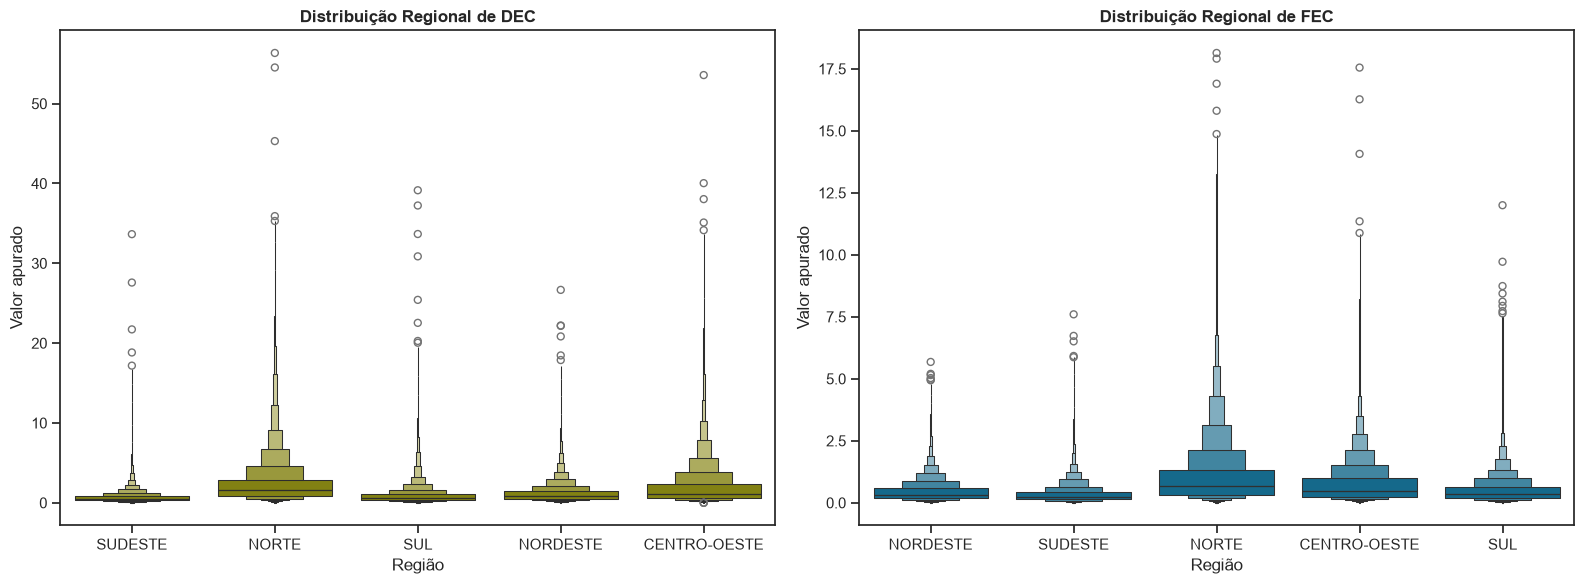

Gráfico salvo com sucesso em: ..\reports\figures\dec_fec_region_distribution.png


In [251]:
# Distribuição regional de DEC e FEC

full_image_path = os.path.join(FIGURES_DIR, "dec_fec_region_distribution.png")
relative_image_path = os.path.relpath(full_image_path)

query_region_distribution = f"""
SELECT
    c.Regiao,
    i.SigIndicador,
    f.VlrIndicador
FROM read_parquet('{FACT_CONT_PATH}') f
JOIN read_parquet('{DIM_CONJUNTO_PATH}') c
  ON f.ConjuntoKey = c.ConjuntoKey
JOIN read_parquet('{DIM_INDICADOR_PATH}') i
  ON f.IndicadorKey = i.IndicadorKey
WHERE c.Regiao IS NOT NULL
  AND c.Regiao <> 'NÃO INFORMADO'
"""

df_region_distribution = con.execute(query_region_distribution).df()

distribution_data = [
    df_region_distribution.loc[df_region_distribution["SigIndicador"] == indicator]
    for indicator in ["DEC", "FEC"]
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
for axis, data, indicator, color in zip(
    axes,
    distribution_data,
    ["DEC", "FEC"],
    colors[:2],
):
    sns.boxenplot(
        data=data,
        x="Regiao",
        y="VlrIndicador",
        color=color,
        ax=axis,
    )
    axis.set_title(f"Distribuição Regional de {indicator}", fontweight="bold")
    axis.set_xlabel("Região")
    axis.set_ylabel("Valor apurado")
    axis.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(relative_image_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo com sucesso em: {relative_image_path}")

- A distribuição regional mostra maior dispersão e valores extremos elevados de DEC na região Norte; o Centro-Oeste também apresenta uma cauda de valores altos.

- Para FEC, a região Norte concentra a maior variabilidade, seguida pelo Centro-Oeste, enquanto Sul e Nordeste apresentam distribuições mais concentradas.


- A região Sudeste exibe a distribuição mais próxima de zero tanto para DEC quanto para FEC, apesar de registrar outliers isolados que demandam atenção pontual.

- Mesmo em regiões com bom desempenho (como Sul e Nordeste), os gráficos revelam ocorrências na cauda superior (DEC ultrapassando 25 a 35), comprovando que contingências pontuais afetam qualquer área geográfica.



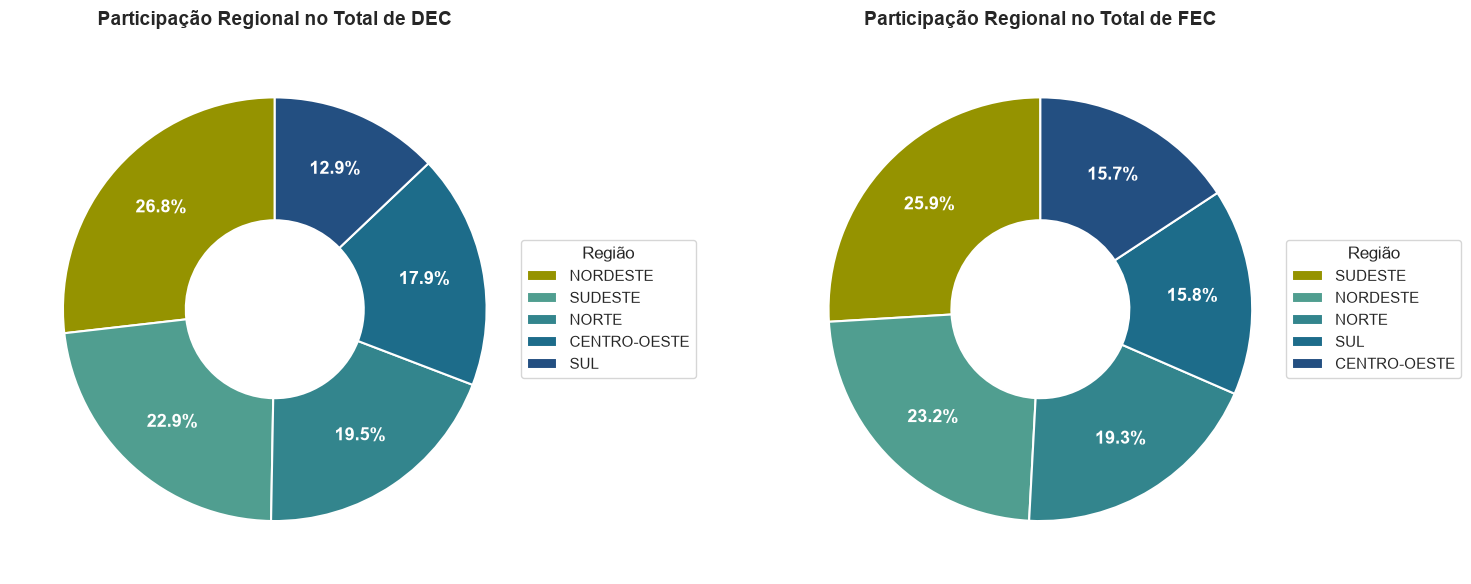

Gráfico salvo com sucesso em: ..\reports\figures\dec_fec_region_share.png


In [274]:
# Participação regional no total apurado de DEC e FEC

full_image_path = os.path.join(FIGURES_DIR, "dec_fec_region_share.png")
relative_image_path = os.path.relpath(full_image_path)

region_share = df_region_distribution.groupby(
    ["SigIndicador", "Regiao"], as_index=False
)["VlrIndicador"].sum()

region_share["percentual_total"] = (
    region_share["VlrIndicador"]
    / region_share.groupby("SigIndicador")["VlrIndicador"].transform("sum")
    * 100
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for axis, indicator in zip(axes, ["DEC", "FEC"]):
    data = (
        region_share[region_share["SigIndicador"] == indicator]
        .sort_values("percentual_total", ascending=False)
        .reset_index(drop=True)
    )

    slice_colors = [colors[0]] + sns.color_palette("crest", n_colors=len(data))[1:]

    wedges, texts, autotexts = axis.pie(
        data["percentual_total"],
        autopct="%.1f%%",
        pctdistance=0.72,
        startangle=90,
        colors=slice_colors,
        wedgeprops={"width": 0.58, "edgecolor": "white", "linewidth": 1.5},
    )

    for autotext in autotexts:
        autotext.set_color("white")
        autotext.set_fontsize(13)
        autotext.set_fontweight("bold")

    axis.set_title(
        f"Participação Regional no Total de {indicator}",
        fontweight="bold",
        fontsize=14,
        pad=14,
    )

    axis.legend(
        wedges,
        data["Regiao"],
        title="Região",
        loc="center left",
        bbox_to_anchor=(0.95, 0.5),
        frameon=True,
        fontsize=11,
        title_fontsize=12,
    )

plt.tight_layout()
plt.savefig(relative_image_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo com sucesso em: {relative_image_path}")


- O Nordeste responde pela maior fatia do tempo total sem energia (`26,8% do DEC`) e quase um quarto das ocorrências (`23,2% do FEC`), enquanto o Sudeste lidera o volume acumulado de interrupções (`25,9% do FEC`) e representa `22,9% do DEC`, refletindo o peso conjunto da extensão da rede e da densidade de consumidores dessas macrorregiões.

- A região Norte, apesar de historicamente atender a uma base menor de unidades consumidoras em comparação aos centros urbanos do Centro-Sul, responde por quase um quinto do impacto total do país (`19,5% do DEC` e `19,3% do FEC`), confirmando maior vulnerabilidade da malha e tempos médios de restabelecimento mais longos.

- A Região Sul apresenta a menor participação no total acumulado de horas sem fornecimento (`12,9% do DEC`) e `15,8% do FEC`, ao passo que a região Centro-Oeste mantém volumes moderados no quadro geral (`17,9% do DEC` e `15,7% do FEC`).

- Embora distribuidoras isoladas de menor porte sofram com percentuais de ultrapassagem críticos, a maior quantidade de horas e eventos que sustentam a regulação nacional está no eixo Nordeste–Sudeste–Norte (somando `~69%` do DEC total).

---

## 7. Análise das interrupções

Neste tópico é explorada a composição das interrupções agregadas por tipo operacional, motivo regulatório e causa normalizada. Os gráficos comparam a quantidade de interrupções e a duração total por tipo.

In [253]:
# Resumo das interrupções por tipo, motivo e causa
query_interruptions = f"""
SELECT
    t.TipoInterrupcao,
    m.MotivoDescricao,
    c.GrupoCausa,
    c.CausaDetalhada,
    SUM(f.QtdInterrupcoes) AS quantidade_interrupcoes,
    ROUND(SUM(f.DuracaoTotalHoras), 2) AS duracao_total_horas,
    ROUND(AVG(f.DuracaoMediaHoras), 2) AS duracao_media_horas,
    SUM(f.UnidadesAfetadasSoma) AS unidades_afetadas,
    ROUND(SUM(f.ConsumidorHoras), 2) AS consumidor_horas
FROM read_parquet('{FACT_CAUSA_PATH}') f
JOIN read_parquet('{DIM_TIPO_PATH}') t
  ON f.TipoInterrupcaoKey = t.TipoInterrupcaoKey
JOIN read_parquet('{DIM_MOTIVO_PATH}') m
  ON f.MotivoInterrupcaoKey = m.MotivoInterrupcaoKey
JOIN read_parquet('{DIM_CAUSA_PATH}') c
  ON f.CausaKey = c.CausaKey
GROUP BY t.TipoInterrupcao, m.MotivoDescricao, c.GrupoCausa, c.CausaDetalhada
ORDER BY quantidade_interrupcoes DESC
"""

df_interruptions = con.execute(query_interruptions).df()
df_interruptions_display = df_interruptions.head(10)
numeric_columns = df_interruptions_display.select_dtypes(include="number").columns
numeric_formats = {column: "{:.2f}" for column in numeric_columns}
display(
    df_interruptions_display.style.format(numeric_formats).set_properties(
        **{"white-space": "normal", "min-width": "100px"}
    )
)

,TipoInterrupcao,MotivoDescricao,GrupoCausa,CausaDetalhada,quantidade_interrupcoes,duracao_total_horas,duracao_media_horas,unidades_afetadas,consumidor_horas
0,NAO PROGRAMADA,Não houve expurgo,INTERNA,FALHA DE MATERIAL OU EQUIPAMENTO,13700888.00,100347865.29,6.69,614212391.00,1107775389.30
1,NAO PROGRAMADA,Não houve expurgo,INTERNA,ARVORE OU VEGETACAO,2686455.00,16898904.78,5.93,269452494.00,614419350.49
2,NAO PROGRAMADA,Não houve expurgo,INTERNA,NAO IDENTIFICADA,2011667.00,7609604.83,4.05,573968004.00,343525276.10
3,NAO PROGRAMADA,Não houve expurgo,INTERNA,DESCARGA ATMOSFERICA,1823198.00,15387236.98,6.76,95442496.00,238168171.51
4,NAO PROGRAMADA,Não houve expurgo,INTERNA,VENTO,1533151.00,9865913.79,5.98,142553751.00,263126744.72
5,NAO PROGRAMADA,Não houve expurgo,INTERNA,ANIMAIS,1518254.00,7500300.37,4.81,121445941.00,217001574.87
6,NAO PROGRAMADA,Situação de emergência,INTERNA,VENTO,1377187.00,16268456.16,10.00,234687034.00,898067484.83
7,NAO PROGRAMADA,Não houve expurgo,INTERNA,NAO CLASSIFICADA,1228203.00,6162097.23,4.94,130803435.00,126102336.49
8,NAO PROGRAMADA,Falha nas instalações da unidade consumidora sem afetar terceiros,INTERNA,DEFEITO INTERNO NAO AFETANDO OUTRAS UNIDADES CONSUMIDORAS,1051906.00,6963909.07,6.66,1209009.00,6714197.18
9,NAO PROGRAMADA,Situação de emergência,INTERNA,DESCARGA ATMOSFERICA,919588.00,10674997.60,9.90,84122955.00,299683785.50


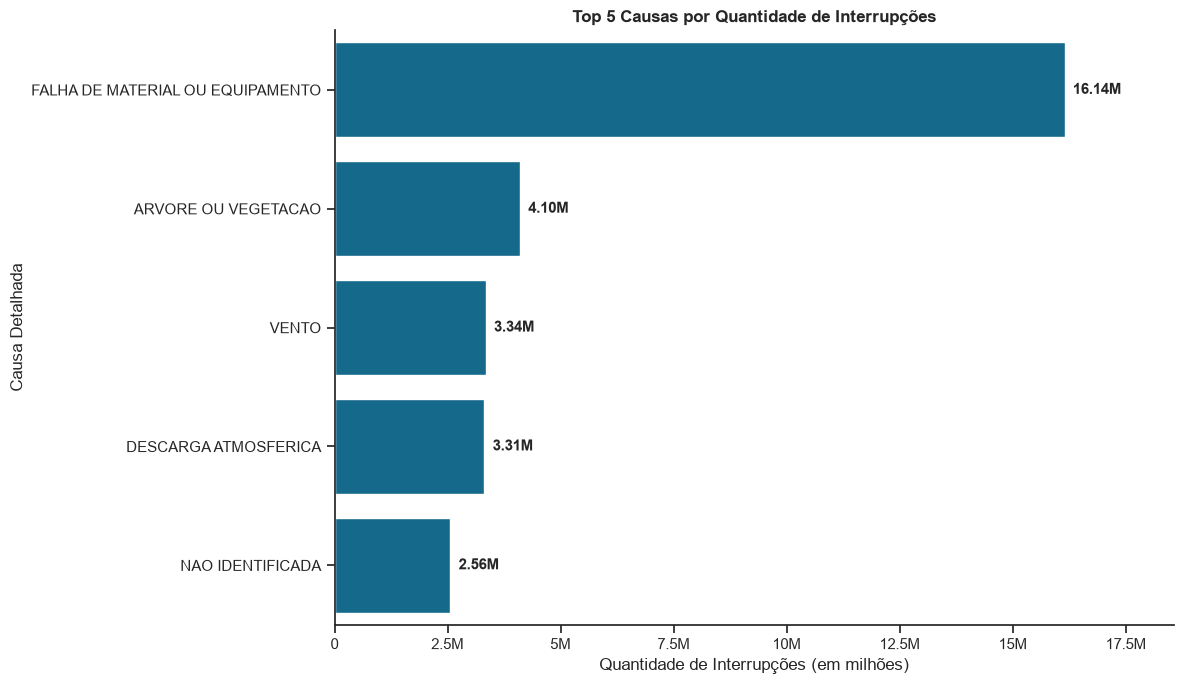

Gráfico salvo com sucesso em: ..\reports\figures\top_5_interruptions_causes.png


In [254]:
# Top 5 causas por quantidade de interrupções

full_image_path = os.path.join(FIGURES_DIR, "top_5_interruptions_causes.png")
relative_image_path = os.path.relpath(full_image_path)

top_5_causes = (
    df_interruptions.groupby("CausaDetalhada", as_index=False)
    .agg(quantidade_interrupcoes=("quantidade_interrupcoes", "sum"))
    .nlargest(5, "quantidade_interrupcoes")
    .sort_values("quantidade_interrupcoes", ascending=False)
)

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=top_5_causes,
    x="quantidade_interrupcoes",
    y="CausaDetalhada",
    order=top_5_causes["CausaDetalhada"],
    color=colors[1],
)

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x, pos: f"{x/1e6:.1f}M".replace(".0M", "M") if x != 0 else "0"
    )
)

ax.bar_label(
    ax.containers[0],
    fmt=lambda x: f"{x/1e6:.2f}M",
    padding=6,
    fontsize=11,
    fontweight="bold",
)

plt.xlim(0, top_5_causes["quantidade_interrupcoes"].max() * 1.15)
plt.title("Top 5 Causas por Quantidade de Interrupções", fontweight="bold")
plt.xlabel("Quantidade de Interrupções (em milhões)")
plt.ylabel("Causa Detalhada")
sns.despine(top=True, right=True)

plt.tight_layout()
plt.savefig(relative_image_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo com sucesso em: {relative_image_path}")

- A causa `Falha de material ou equipamento` lidera isolada em volume (13,7 milhões de interrupções) e tempo acumulado (mais de 100 milhões de horas), afetando mais de 614 milhões de unidades consumidoras sem expurgo regulatório.

- `Árvore ou vegetação` (2,68 milhões de eventos e 16,89 milhões de horas) e `Descarga atmosférica` (1,82 milhões de eventos e 15,38 milhões de horas) constituem os principais vetores ambientais de descontinuidade do serviço.

- A categoria `Vento` associada a `Situação de emergência` destaca-se pela maior duração média por ocorrência (10,00 horas), resultando em 16,26 milhões de horas de corte e mais de 234 milhões de unidades afetadas

- As categorias `Não identificada` e `Não classificada` somam juntas mais de 3,23 milhões de interrupções e quase 13,8 milhões de horas sem causa aparente registada, indicando uma oportunidade de melhoria na governança de dados e diagnóstico de campo pelas concessionárias.

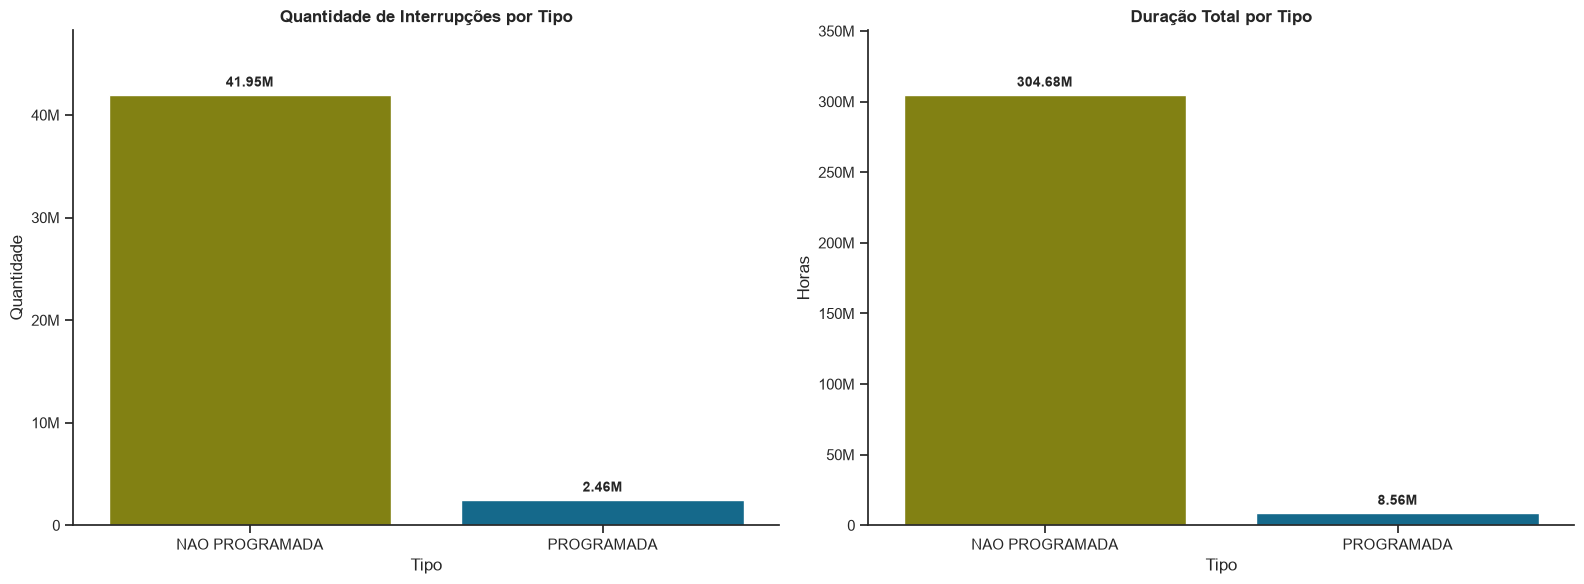

Gráfico salvo com sucesso em: ..\reports\figures\interruptions_by_type.png


In [255]:
# Distribuição das interrupções por tipo operacional

full_image_path = os.path.join(FIGURES_DIR, "interruptions_by_type.png")
relative_image_path = os.path.relpath(full_image_path)

interruptions_by_type = (
    df_interruptions.groupby("TipoInterrupcao", as_index=False)
    .agg(
        quantidade_interrupcoes=("quantidade_interrupcoes", "sum"),
        duracao_total_horas=("duracao_total_horas", "sum"),
        consumidor_horas=("consumidor_horas", "sum"),
    )
    .sort_values("quantidade_interrupcoes", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

formatter_million = ticker.FuncFormatter(
    lambda y, pos: f"{y/1e6:.1f}M".replace(".0M", "M") if y != 0 else "0"
)

bar_palette = [colors[0], colors[1]]

sns.barplot(
    data=interruptions_by_type,
    x="TipoInterrupcao",
    y="quantidade_interrupcoes",
    hue="TipoInterrupcao",
    palette=bar_palette,
    ax=axes[0],
)
axes[0].set_title("Quantidade de Interrupções por Tipo", fontweight="bold")
axes[0].set_xlabel("Tipo")
axes[0].set_ylabel("Quantidade")
axes[0].tick_params(axis="x", rotation=0)
axes[0].yaxis.set_major_formatter(formatter_million)

for container in axes[0].containers:
    axes[0].bar_label(
        container,
        fmt=lambda y: f"{y/1e6:.2f}M",
        padding=4,
        fontsize=10,
        fontweight="bold",
    )
axes[0].set_ylim(0, interruptions_by_type["quantidade_interrupcoes"].max() * 1.15)
sns.despine(ax=axes[0], top=True, right=True)

sns.barplot(
    data=interruptions_by_type,
    x="TipoInterrupcao",
    y="duracao_total_horas",
    hue="TipoInterrupcao",
    palette=bar_palette,
    ax=axes[1],
)
axes[1].set_title("Duração Total por Tipo", fontweight="bold")
axes[1].set_xlabel("Tipo")
axes[1].set_ylabel("Horas")
axes[1].yaxis.set_major_formatter(formatter_million)

for container in axes[1].containers:
    axes[1].bar_label(
        container,
        fmt=lambda y: f"{y/1e6:.2f}M",
        padding=4,
        fontsize=10,
        fontweight="bold",
    )
axes[1].set_ylim(0, interruptions_by_type["duracao_total_horas"].max() * 1.15)
sns.despine(ax=axes[1], top=True, right=True)

plt.tight_layout()
plt.savefig(relative_image_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo com sucesso em: {relative_image_path}")

- As ocorrências do tipo "Não Programada" superam os 40 milhões de eventos e acumulam mais de 300 milhões de horas de indisponibilidade, tornando as paradas "Programadas" residuais no balanço global do sistema.

- Os dados comprovam que as manutenções programadas exercem um impacto quase imperceptível no DEC, validando que o risco regulatório e a formação de passivos operacionais derivam aparentemente de falhas acidentais e emergenciais.

---

## 8. Análise de outliers

Neste tópico, o gráfico investiga os dez grupos com maior duração total de interrupções, relacionando-os à distribuidora, região, grupo de causa e causa detalhada para avaliar a causa dos outliers.

In [256]:
# Grupos com maior duração total de interrupções
query_outlier_groups = f"""
SELECT
    d.SigAgente,
    c.Regiao,
    ca.GrupoCausa,
    ca.CausaDetalhada,
    SUM(f.DuracaoTotalHoras) AS duracao_total_horas,
    SUM(f.QtdInterrupcoes) AS quantidade_interrupcoes,
    SUM(f.UnidadesAfetadasSoma) AS unidades_afetadas,
    SUM(f.ConsumidorHoras) AS consumidor_horas
FROM read_parquet('{FACT_CAUSA_PATH}') f
JOIN read_parquet('{DIM_DISTRIBUIDORA_PATH}') d
  ON f.DistribuidoraKey = d.DistribuidoraKey
JOIN read_parquet('{DIM_CONJUNTO_PATH}') c
  ON f.ConjuntoKey = c.ConjuntoKey
JOIN read_parquet('{DIM_CAUSA_PATH}') ca
  ON f.CausaKey = ca.CausaKey
GROUP BY d.SigAgente, c.Regiao, ca.GrupoCausa, ca.CausaDetalhada
ORDER BY duracao_total_horas DESC
LIMIT 10
"""

df_outlier_groups = con.execute(query_outlier_groups).df()
display(df_outlier_groups)

,SigAgente,Regiao,GrupoCausa,CausaDetalhada,duracao_total_horas,quantidade_interrupcoes,unidades_afetadas,consumidor_horas
0,LIGHT SESA,SUDESTE,INTERNA,FALHA DE MATERIAL OU EQUIPAMENTO,12652143.39,941519.00,38377524.00,109310513.35
1,CEMIG-D,SUDESTE,INTERNA,FALHA DE MATERIAL OU EQUIPAMENTO,10731890.12,1951960.00,56955043.00,112370010.74
2,EQUATORIAL PA,NORTE,INTERNA,FALHA DE MATERIAL OU EQUIPAMENTO,9780980.59,1120721.00,39635006.00,88089162.08
3,EQUATORIAL MA,NORDESTE,INTERNA,FALHA DE MATERIAL OU EQUIPAMENTO,8430802.97,1069130.00,30625077.00,84918002.73
4,ENEL CE,NORDESTE,INTERNA,FALHA DE MATERIAL OU EQUIPAMENTO,8070679.55,976160.00,28648397.00,70627287.44
5,ENEL RJ,SUDESTE,INTERNA,FALHA DE MATERIAL OU EQUIPAMENTO,7564250.97,1081442.00,22967730.00,57443121.31
6,EQUATORIAL PI,NORDESTE,INTERNA,FALHA DE MATERIAL OU EQUIPAMENTO,7323100.38,798265.00,22689802.00,63790861.28
7,ELETROPAULO,SUDESTE,INTERNA,FALHA DE MATERIAL OU EQUIPAMENTO,6991103.23,765930.00,33831801.00,74170040.35
8,EQUATORIAL AL,NORDESTE,INTERNA,FALHA DE MATERIAL OU EQUIPAMENTO,6100973.59,586141.00,28135429.00,84872968.56
9,CEMIG-D,SUDESTE,INTERNA,NAO CLASSIFICADA,5129990.00,810711.00,64504477.00,131793465.18


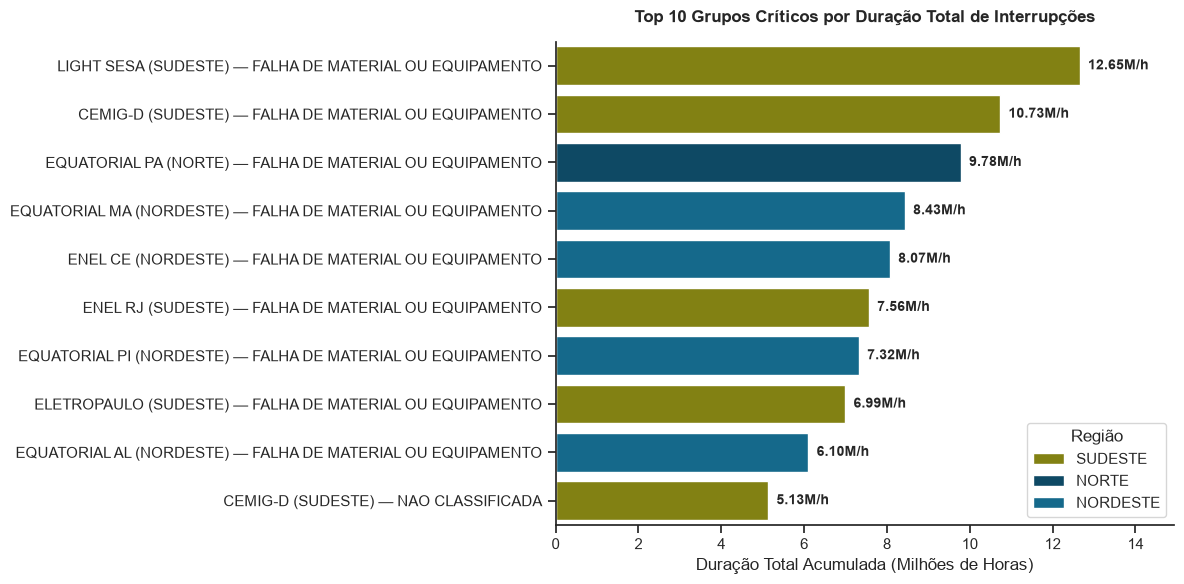

Gráfico salvo com sucesso em: ..\reports\figures\interruptions_by_type.png


In [257]:
# Distribuição dos grupos extremos por região

full_image_path = os.path.join(FIGURES_DIR, "interruptions_by_type.png")
relative_image_path = os.path.relpath(full_image_path)

df_top10 = df_outlier_groups.head(10).copy()
df_top10["duracao_milhoes_horas"] = df_top10["duracao_total_horas"] / 1e6

# Cria um rótulo claro combinando Agente, Região e Causa
df_top10["rotulo_grupo"] = (
    df_top10["SigAgente"]
    + " ("
    + df_top10["Regiao"]
    + ") — "
    + df_top10["CausaDetalhada"]
)

df_top10 = df_top10.sort_values("duracao_milhoes_horas", ascending=False)

plt.figure(figsize=(12, 6))

bar_palette = [colors[0], colors[2], colors[1]]

ax = sns.barplot(
    data=df_top10,
    y="rotulo_grupo",
    x="duracao_milhoes_horas",
    hue="Regiao",
    dodge=False,
    palette=bar_palette,
)

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{width:.2f}M/h",
            (width, p.get_y() + p.get_height() / 2.0),
            xytext=(6, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=10,
            fontweight="bold",
        )

plt.title(
    "Top 10 Grupos Críticos por Duração Total de Interrupções",
    fontweight="bold",
    pad=14,
)
plt.xlabel("Duração Total Acumulada (Milhões de Horas)")
plt.ylabel("")
plt.xlim(0, df_top10["duracao_milhoes_horas"].max() * 1.18)  # Espaço para os textos
plt.legend(title="Região", loc="lower right", frameon=True)
sns.despine(top=True, right=True)

plt.tight_layout()
plt.savefig(relative_image_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo com sucesso em: {relative_image_path}")

- 9 das 10 posições do ranking pertencem à causa `FALHA DE MATERIAL OU EQUIPAMENTO`, sendo classificada invariavelmente no grupo de origem `INTERNA` e distribuídas nas regiões Norte, Nordeste e Sudeste.

- A LIGHT SESA (Sudeste) lidera isolada com mais de `12,65` milhões de horas e `38,37` milhões de consumidores afetados, seguida pela CEMIG-D com `10,73` milhões de horas e `56,95` milhões de consumidores afetados.

- A vulnerabilidade de componentes da rede repete-se com volumes expressivos no Norte (Equatorial PA com `9,78M horas`), Nordeste (Equatorial MA com `8,43M horas` e ENEL CE com `8,07M horas`) e novamente no Sudeste (ENEL RJ com `7,56M horas`).

---

## 9. Relações entre variáveis

A matriz de correlação avalia associações lineares entre `VlrIndicador`, `VlrLimite`, `ExcessoSobreLimite` e `PercentualDoLimite`. Correlação indica associação estatística, mas não demonstra causalidade.

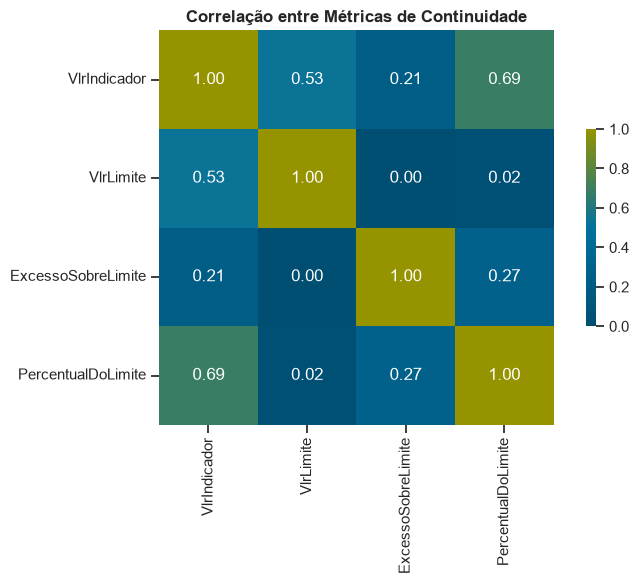

Gráfico salvo com sucesso em: ..\reports\figures\correlation_matrix.png


In [258]:
# Matriz de correlação entre métricas numéricas agregadas
query_correlation = f"""
SELECT
    VlrIndicador,
    VlrLimite,
    ExcessoSobreLimite,
    PercentualDoLimite
FROM read_parquet('{FACT_CONT_PATH}')
"""

df_correlation_cont = con.execute(query_correlation).df()
correlation_matrix = df_correlation_cont.corr(numeric_only=True)

full_image_path = os.path.join(FIGURES_DIR, "correlation_matrix.png")
relative_image_path = os.path.relpath(full_image_path)

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap=sns.blend_palette(colors[::-1], as_cmap=True),
    vmin=0,
    vmax=1,
    square=True,
    cbar_kws={"shrink": 0.5},
)
plt.title("Correlação entre Métricas de Continuidade", fontweight="bold")

plt.tight_layout()
plt.savefig(relative_image_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo com sucesso em: {relative_image_path}")

- `VlrIndicador` e `PercentualDoLimite` apresentam correlação positiva de `0,69`, indicando que valores apurados maiores tendem a estar associados a maior proporção do limite utilizada.

- `VlrIndicador` e `VlrLimite` apresentam correlação moderada de `0,53`, refletindo diferenças entre conjuntos e indicadores regulatórios.

- `VlrLimite` e `ExcessoSobreLimite` apresentam correlação praticamente nula (`0,00`), sugerindo que o valor do limite, isoladamente, não explica o excesso observado.

- `ExcessoSobreLimite` e `PercentualDoLimite` apresentam correlação baixa (`0,27`), pois representam aspectos relacionados, mas não equivalentes, da ultrapassagem.

---

## 10. Perguntas de partida, hipóteses e insights

Esta seção organiza as perguntas que orientam a investigação exploratória e relaciona cada hipótese aos resultados observados nos tópicos anteriores.

### 10.1. Conjuntos com histórico de transgressões apresentam maior risco de reincidência?

>**Hipótese 01:** Os conjuntos com histórico mais frequente de transgressões de DEC/FEC apresentam maior probabilidade de ultrapassar o limite no período seguinte.

In [259]:
# Avaliação da hipótese 1: histórico anterior versus transgressão no mês seguinte
query_hypothesis_1 = f"""
WITH base AS (
    SELECT
        f.ConjuntoKey,
        i.SigIndicador,
        d.Data,
        CAST(f.UltrapassouLimite AS INTEGER) AS transgressao
    FROM read_parquet('{FACT_CONT_PATH}') f
    JOIN read_parquet('{DIM_DATA_PATH}') d
      ON f.DataKey = d.DataKey
    JOIN read_parquet('{DIM_INDICADOR_PATH}') i
      ON f.IndicadorKey = i.IndicadorKey
),
ordered AS (
    SELECT
        *,
        SUM(transgressao) OVER (
            PARTITION BY ConjuntoKey, SigIndicador
            ORDER BY Data
            ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
        ) AS historico_transgressoes,
        COUNT(*) OVER (
            PARTITION BY ConjuntoKey, SigIndicador
            ORDER BY Data
            ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
        ) AS historico_periodos,
        LEAD(transgressao) OVER (
            PARTITION BY ConjuntoKey, SigIndicador
            ORDER BY Data
        ) AS transgressao_seguinte
    FROM base
),
prepared AS (
    SELECT
        *,
        COALESCE(historico_transgressoes, 0) AS historico_transgressoes_real,
        COALESCE(historico_periodos, 0) AS historico_periodos_real
    FROM ordered
    WHERE transgressao_seguinte IS NOT NULL
)
SELECT
    SigIndicador,
    CASE
        WHEN historico_transgressoes_real = 0 THEN '0 transgressões'
        WHEN historico_transgressoes_real BETWEEN 1 AND 2 THEN '1-2 transgressões'
        WHEN historico_transgressoes_real BETWEEN 3 AND 5 THEN '3-5 transgressões'
        ELSE '6 ou mais transgressões'
    END AS faixa_historico,
    COUNT(*) AS observacoes,
    SUM(transgressao_seguinte) AS transgressoes_seguinte,
    ROUND(100.0 * AVG(transgressao_seguinte), 2) AS risco_periodo_seguinte
FROM prepared
GROUP BY SigIndicador, faixa_historico
ORDER BY SigIndicador, faixa_historico
"""

df_hypothesis_1 = con.execute(query_hypothesis_1).df()
display(df_hypothesis_1)

,SigIndicador,faixa_historico,observacoes,transgressoes_seguinte,risco_periodo_seguinte
0,DEC,0 transgressões,182315,47.00,0.03
1,DEC,1-2 transgressões,1333,18.00,1.35
2,DEC,3-5 transgressões,119,10.00,8.40
3,DEC,6 ou mais transgressões,14,3.00,21.43
4,FEC,0 transgressões,183498,9.00,0.00
5,FEC,1-2 transgressões,155,3.00,1.94


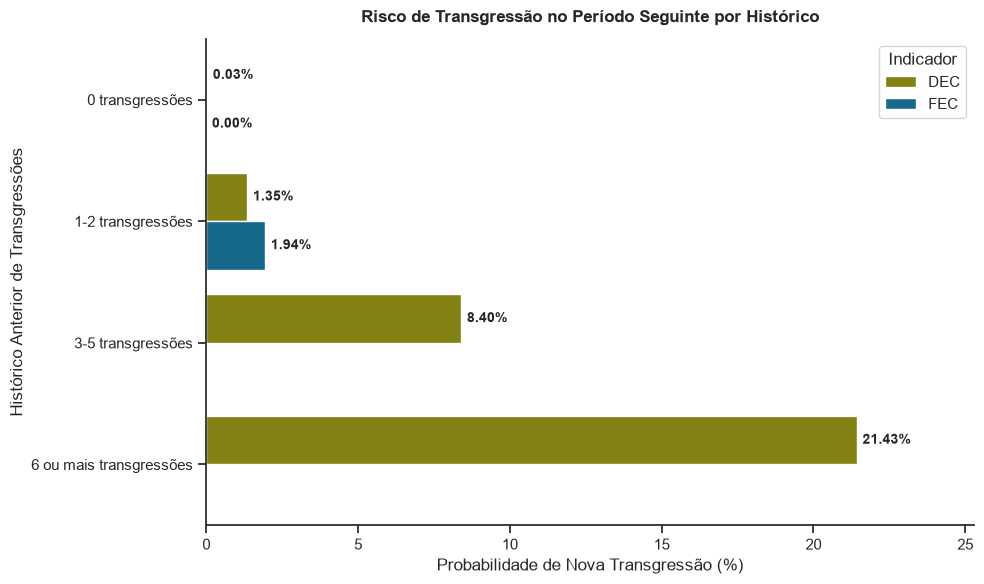

Gráfico salvo com sucesso em: ..\reports\figures\hypothesis_1_overtaking_risk.png


In [260]:
# Gráfico do risco de transgressão seguinte por faixa de histórico

full_image_path = os.path.join(FIGURES_DIR, "hypothesis_1_overtaking_risk.png")
relative_image_path = os.path.relpath(full_image_path)

plot_data = df_hypothesis_1.copy()
plot_data["faixa_historico"] = pd.Categorical(
    plot_data["faixa_historico"],
    categories=[
        "0 transgressões",
        "1-2 transgressões",
        "3-5 transgressões",
        "6 ou mais transgressões",
    ],
    ordered=True,
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=plot_data,
    y="faixa_historico",
    x="risco_periodo_seguinte",
    hue="SigIndicador",
    palette=colors[:2],
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=4,
        fontsize=10,
        fontweight="bold",
    )

plt.xlim(0, plot_data["risco_periodo_seguinte"].max() * 1.18)
plt.title(
    "Risco de Transgressão no Período Seguinte por Histórico",
    fontweight="bold",
    pad=12,
)

plt.ylabel("Histórico Anterior de Transgressões")
plt.xlabel("Probabilidade de Nova Transgressão (%)")
plt.legend(title="Indicador", loc="upper right", frameon=True)
sns.despine(top=True, right=True)

plt.tight_layout()
plt.savefig(relative_image_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Gráfico salvo com sucesso em: {relative_image_path}")

**Veredito:** 
> **Hipótese Confirmada!**
O histórico de violações é um forte preditor de reincidência, especialmente para o DEC, onde a probabilidade de nova transgressão salta de `0,03%` (sem histórico) para `21,43%` (6 ou mais transgressões).

- Para DEC, observa-se uma relação crescente entre o histórico de transgressões e o risco no período seguinte: `0,03%` sem histórico, `1,35%` com 1-2 ocorrências, `8,40%` com 3-5 e `21,43%` com 6 ou mais.

- Conjuntos elétricos com histórico crônico ($\ge 6$ falhas) têm uma chance mais de `700 vezes maior` de violar a meta de duração no período seguinte em relação a conjuntos estáveis (`21,43%` contra `0,03%`).

- Para FEC, as reincidências severas inexistem ou são residuais, indicando que a quebra de metas é essencialmente um problema de tempo de restabelecimento (DEC) e não de quantidade repetida de interrupções no mesmo período.

---

### 10.2. As interrupções não programadas apresentam maior impacto operacional?

>**Hipótese 02:** As interrupções não programadas apresentam maior contribuição para o impacto operacional e para a variação do DEC do que interrupções programadas.

In [261]:
# Comparação da contribuição operacional e estimada ao DEC por tipo de interrupção
query_hypothesis_2 = f"""
SELECT
    t.TipoInterrupcao,
    SUM(f.QtdInterrupcoes) AS quantidade_interrupcoes,
    ROUND(SUM(f.DuracaoTotalHoras), 2) AS duracao_total_horas,
    SUM(f.UnidadesAfetadasSoma) AS unidades_afetadas,
    ROUND(SUM(f.ConsumidorHoras), 2) AS consumidor_horas,
    ROUND(SUM(f.ContribDEC_Estimada), 2) AS contribuicao_dec_estimada
FROM read_parquet('{FACT_CAUSA_PATH}') f
JOIN read_parquet('{DIM_TIPO_PATH}') t
  ON f.TipoInterrupcaoKey = t.TipoInterrupcaoKey
GROUP BY t.TipoInterrupcao
ORDER BY contribuicao_dec_estimada DESC
"""

df_hypothesis_2 = con.execute(query_hypothesis_2).df()
display(df_hypothesis_2)

,TipoInterrupcao,quantidade_interrupcoes,duracao_total_horas,unidades_afetadas,consumidor_horas,contribuicao_dec_estimada
0,NAO PROGRAMADA,41949436.00,304675545.33,4116357244.00,7576866561.69,328886.23
1,PROGRAMADA,2461384.00,8559807.98,363672012.00,490325675.69,19036.97


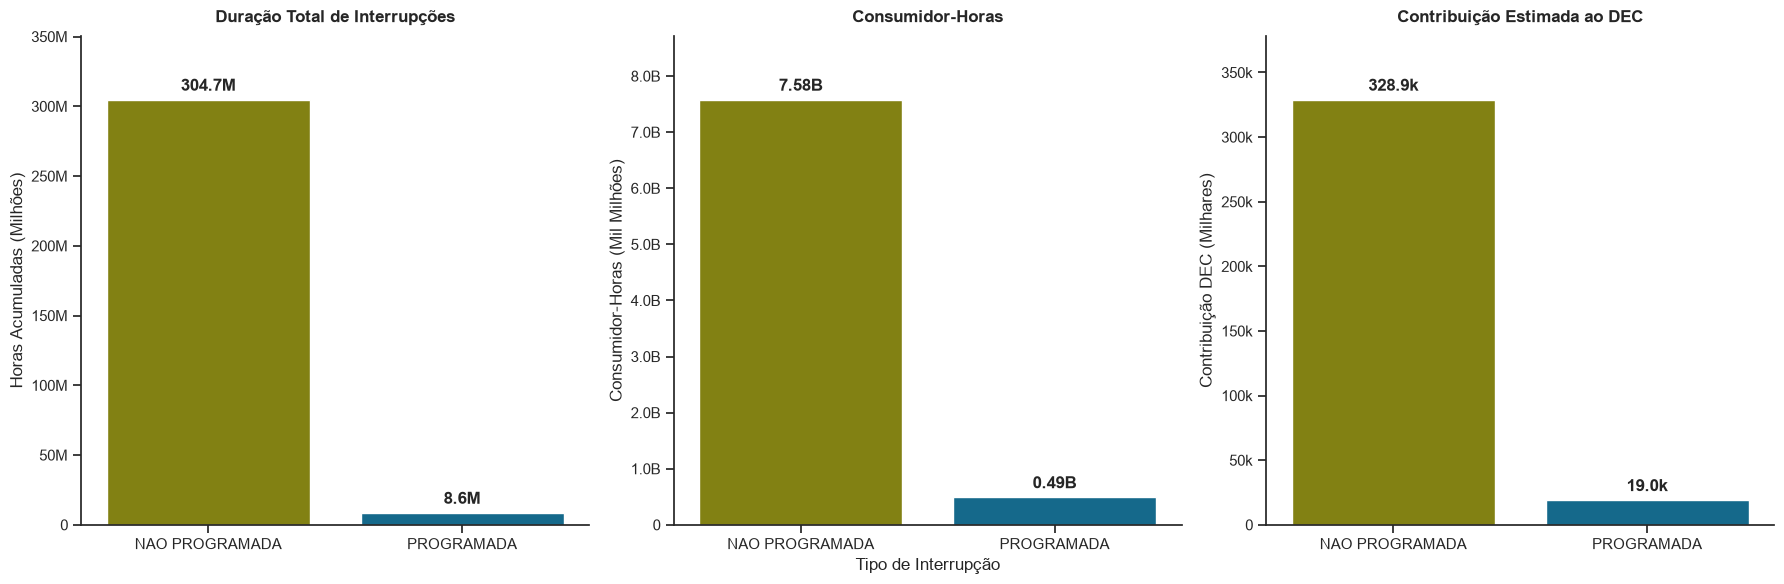

Gráfico guardado com sucesso em: ..\reports\figures\hypothesis_2_unplanned_impact.png


In [262]:
# Gráfico comparativo da contribuição operacional e estimada ao DEC

full_image_path = os.path.join(FIGURES_DIR, "hypothesis_2_unplanned_impact.png")
relative_image_path = os.path.relpath(full_image_path)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
bar_palette = [colors[0], colors[1]]

# 1. Duração Total (Horas) em Milhões
sns.barplot(
    data=df_hypothesis_2,
    x="TipoInterrupcao",
    y="duracao_total_horas",
    hue="TipoInterrupcao",
    palette=bar_palette,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Duração Total de Interrupções", fontweight="bold", pad=10)
axes[0].set_xlabel("")
axes[0].set_ylabel("Horas Acumuladas (Milhões)")
axes[0].yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda y, pos: f"{y/1e6:.0f}M" if y != 0 else "0")
)
for container in axes[0].containers:
    axes[0].bar_label(
        container, fmt=lambda y: f"{y/1e6:.1f}M", padding=4, fontweight="bold"
    )
axes[0].set_ylim(0, df_hypothesis_2["duracao_total_horas"].max() * 1.15)
sns.despine(ax=axes[0], top=True, right=True)

# 2. Consumidor-Horas em Biliões / Milhares de Milhões
sns.barplot(
    data=df_hypothesis_2,
    x="TipoInterrupcao",
    y="consumidor_horas",
    hue="TipoInterrupcao",
    palette=bar_palette,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Consumidor-Horas", fontweight="bold", pad=10)
axes[1].set_xlabel("Tipo de Interrupção")
axes[1].set_ylabel("Consumidor-Horas (Mil Milhões)")
axes[1].yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda y, pos: f"{y/1e9:.1f}B" if y != 0 else "0")
)
for container in axes[1].containers:
    axes[1].bar_label(
        container, fmt=lambda y: f"{y/1e9:.2f}B", padding=4, fontweight="bold"
    )
axes[1].set_ylim(0, df_hypothesis_2["consumidor_horas"].max() * 1.15)
sns.despine(ax=axes[1], top=True, right=True)

# 3. Contribuição DEC Estimada em Milhares
sns.barplot(
    data=df_hypothesis_2,
    x="TipoInterrupcao",
    y="contribuicao_dec_estimada",
    hue="TipoInterrupcao",
    palette=bar_palette,
    legend=False,
    ax=axes[2],
)
axes[2].set_title("Contribuição Estimada ao DEC", fontweight="bold", pad=10)
axes[2].set_xlabel("")
axes[2].set_ylabel("Contribuição DEC (Milhares)")
axes[2].yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda y, pos: f"{y/1e3:.0f}k" if y != 0 else "0")
)
for container in axes[2].containers:
    axes[2].bar_label(
        container, fmt=lambda y: f"{y/1e3:.1f}k", padding=4, fontweight="bold"
    )
axes[2].set_ylim(0, df_hypothesis_2["contribuicao_dec_estimada"].max() * 1.15)
sns.despine(ax=axes[2], top=True, right=True)

plt.tight_layout()
plt.savefig(relative_image_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Gráfico guardado com sucesso em: {relative_image_path}")

**Veredito**

> **Hipótese Confirmada**! As interrupções não programadas concentram a quase totalidade do impacto operacional e da formação da duração equivalente de interrupção (DEC).

- As interrupções não programadas apresentam maior frequência, duração total, unidades afetadas e consumidor-horas.

- As ocorrências do tipo `NAO PROGRAMADA` registam `41,95` milhões de eventos e `304,68` milhões de horas acumuladas, contra apenas `2,46` milhões de eventos e `8,56` milhões de horas de ocorrências do tipo `PROGRAMADA`.

- Em termos de `consumidor_horas`, o regime não programado ultrapassa `7,57 Bilhões`, o que representa cerca de `93,9%` de todo o impacto acumulado na base de clientes.

- A `contribuicao_dec_estimada` atinge `328.886,23` nas `NAO PROGRAMADAS` versus `19.035,97` nas `PROGRAMADAS`, isto é, `94,5%` do DEC apurado deriva diretamente de falhas acidentais e/ou emergenciais.

---

### 10.3. Existem concentrações regionais ou sazonais de criticidade?

>**Hipótese 03:** Determinados meses, regiões ou distribuidoras concentram níveis maiores de DEC, FEC ou ultrapassagens regulatórias.

In [263]:
# Percentual de ultrapassagem por região, mês e indicador
query_hypothesis_3 = f"""
SELECT
    c.Regiao,
    d.MesNumero,
    i.SigIndicador,
    COUNT(*) AS observacoes,
    ROUND(AVG(f.VlrIndicador), 2) AS media_apurada,
    ROUND(100.0 * AVG(f.UltrapassouLimite), 2) AS percentual_ultrapassagem
FROM read_parquet('{FACT_CONT_PATH}') f
JOIN read_parquet('{DIM_CONJUNTO_PATH}') c
  ON f.ConjuntoKey = c.ConjuntoKey
JOIN read_parquet('{DIM_DATA_PATH}') d
  ON f.DataKey = d.DataKey
JOIN read_parquet('{DIM_INDICADOR_PATH}') i
  ON f.IndicadorKey = i.IndicadorKey
WHERE c.Regiao IS NOT NULL
  AND c.Regiao <> 'NÃO INFORMADO'
GROUP BY c.Regiao, d.MesNumero, i.SigIndicador
ORDER BY c.Regiao, d.MesNumero, i.SigIndicador
"""

df_hypothesis_3 = con.execute(query_hypothesis_3).df()
display(df_hypothesis_3.head(20))

,Regiao,MesNumero,SigIndicador,observacoes,media_apurada,percentual_ultrapassagem
0,CENTRO-OESTE,1,DEC,1690,2.42,0.30
1,CENTRO-OESTE,1,FEC,1690,0.86,0.06
2,CENTRO-OESTE,2,DEC,1690,2.11,0.24
3,CENTRO-OESTE,2,FEC,1690,0.77,0.00
4,CENTRO-OESTE,3,DEC,1690,2.04,0.00
5,CENTRO-OESTE,3,FEC,1690,0.80,0.00
6,CENTRO-OESTE,4,DEC,1690,1.63,0.06
7,CENTRO-OESTE,4,FEC,1690,0.66,0.00
8,CENTRO-OESTE,5,DEC,1690,1.24,0.00
9,CENTRO-OESTE,5,FEC,1690,0.57,0.00


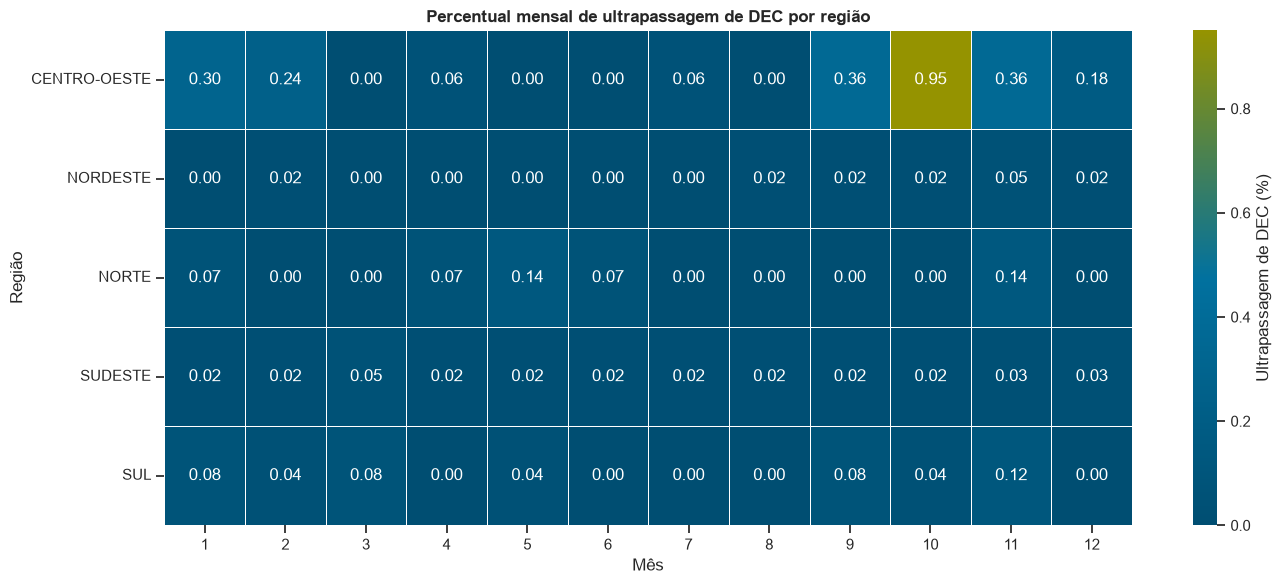

Gráfico guardado com sucesso em: ..\reports\figures\hypothesis_3_regional_seasonality.png


In [264]:
# Heatmap do percentual de ultrapassagem por região e mês

full_image_path = os.path.join(FIGURES_DIR, "hypothesis_3_regional_seasonality.png")
relative_image_path = os.path.relpath(full_image_path)

heatmap_data = df_hypothesis_3[df_hypothesis_3["SigIndicador"] == "DEC"].pivot(
    index="Regiao",
    columns="MesNumero",
    values="percentual_ultrapassagem",
)

plt.figure(figsize=(14, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap=sns.blend_palette(colors[::-1], as_cmap=True),
    linewidths=0.5,
    cbar_kws={"label": "Ultrapassagem de DEC (%)"},
)
plt.title("Percentual mensal de ultrapassagem de DEC por região", fontweight="bold")
plt.xlabel("Mês")
plt.ylabel("Região")

plt.tight_layout()
plt.savefig(relative_image_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Gráfico guardado com sucesso em: {relative_image_path}")

**Veredito**

>Hipótese Confirmada. Existem concentrações regionais e sazonais nítidas, com destaque para a vulnerabilidade crítica da região Centro-Oeste durante a transição do período seco para a estação chuvosa (setembro a novembro).

- O mês de outubro no Centro-Oeste registra o valor crítico nacional de `0,95%` de ultrapassagem de DEC, antecedido por setembro (`0,36%`) e seguido por novembro (`0,36%`). Esse comportamento coincide com o início da estação chuvosa após meses de estiagem e queimadas na região.

- Os meses de janeiro (`0,30%`) e fevereiro (`0,24%`) também mostram níveis elevados de descumprimento no Centro-Oeste, enquanto a média apurada de DEC atinge seu teto (`2,42 horas` em janeiro e `2,11 horas` em fevereiro).   

- O Sudeste mantém uma taxa basal constante e controlada ao longo de todos os meses, com maior variabilidade entre fevereiro (`0,02`) e março (`0,05`).

- O Nordeste apresenta o menor volume de ultrapassagens (a maior parte entre `0,00%` e `0,02%`), com pico de `0,05%` em novembro.   

- O Norte e o Sul operam em faixas intermediárias com pequenos picos isolados no início e no fim do ano (novembro com `0,12%` no Sul e `0,14%` no Norte).  

---

### 10.4. Conjuntos que concentram mais unidades consumidoras apresentam menor tempo médio de interrupção?

>**Hipótese 04:** Conjuntos com maior quantidade cadastral de unidades consumidoras apresentam menor tempo médio de interrupção.


**Nota:** A quantidade é estimada pela soma dos indicadores cadastrais `NUCT*` disponíveis em `atributos.parquet`. Essa medida quantifica o volume de unidades consumidoras, e não a densidade demográfica ou espacial. Logo, a análise afere a associação exploratória entre a escala de atendimento cadastral e a duração média das interrupções, sem isolar efeitos de dispersão geográfica da rede.

In [265]:
# Quantidade cadastral de unidades consumidoras versus DEC
query_hypothesis_4 = f"""
WITH consumidores AS (
    SELECT
        IdeConjunto,
        SUM(TRY_CAST(REPLACE(VlrIndiceEnviado, ',', '.') AS DOUBLE)) AS unidades_consumidoras
    FROM read_parquet('{PROJECT_ROOT / "data" / "interim" / "atributos.parquet"}')
    WHERE SigIndicador LIKE 'NUCT%'
    GROUP BY IdeConjunto
),
dec AS (
    SELECT
        f.ConjuntoKey,
        c.IdeConjunto,
        AVG(f.VlrIndicador) AS dec_medio
    FROM read_parquet('{FACT_CONT_PATH}') f
    JOIN read_parquet('{DIM_CONJUNTO_PATH}') c
      ON f.ConjuntoKey = c.ConjuntoKey
    JOIN read_parquet('{DIM_INDICADOR_PATH}') i
      ON f.IndicadorKey = i.IndicadorKey
    WHERE i.SigIndicador = 'DEC'
    GROUP BY f.ConjuntoKey, c.IdeConjunto
),
base AS (
    SELECT
        d.IdeConjunto,
        d.dec_medio,
        consumidores.unidades_consumidoras,
        CASE
            WHEN consumidores.unidades_consumidoras < 1000 THEN 'Até 1.000'
            WHEN consumidores.unidades_consumidoras < 10000 THEN '1.000 a 10.000'
            WHEN consumidores.unidades_consumidoras < 50000 THEN '10.000 a 50.000'
            ELSE '50.000 ou mais'
        END AS faixa_consumidores
    FROM dec d
    JOIN consumidores USING (IdeConjunto)
)
SELECT
    faixa_consumidores,
    COUNT(*) AS conjuntos,
    ROUND(AVG(unidades_consumidoras), 2) AS media_consumidores,
    ROUND(AVG(dec_medio), 2) AS dec_medio
FROM base
GROUP BY faixa_consumidores
ORDER BY media_consumidores
"""

df_hypothesis_4 = con.execute(query_hypothesis_4).df()
display(df_hypothesis_4)

,faixa_consumidores,conjuntos,media_consumidores,dec_medio
0,Até 1.000,258,261.60,1.19
1,1.000 a 10.000,88,3195.38,1.18
2,10.000 a 50.000,62,24945.27,0.92
3,50.000 ou mais,10,59238.90,2.35


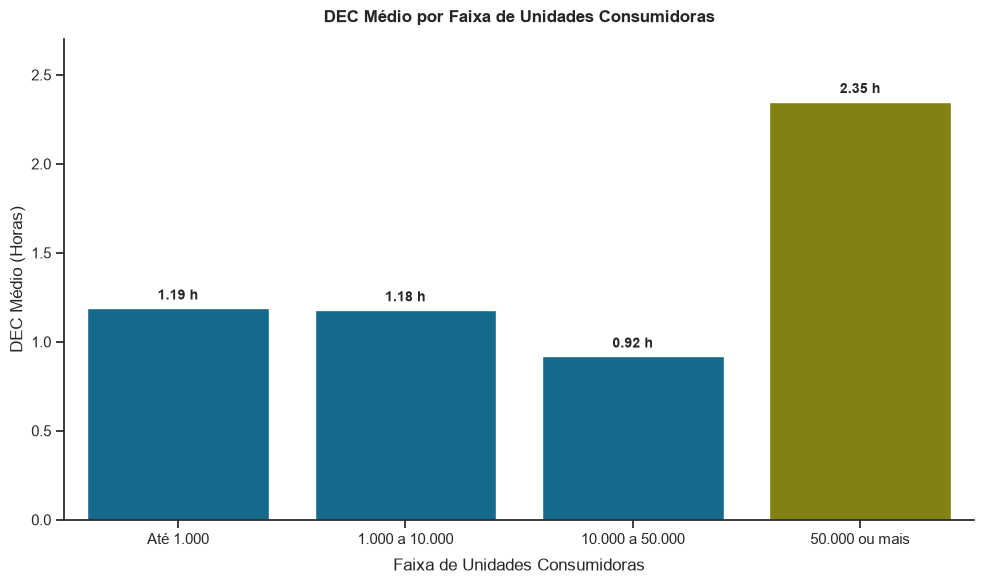

Gráfico salvo com sucesso em: ..\reports\figures\hypothesis_4_dec_by_consumer_size.png


In [266]:
# Gráfico da relação entre faixa de consumidores e DEC médio

full_image_path = os.path.join(FIGURES_DIR, "hypothesis_4_dec_by_consumer_size.png")
relative_image_path = os.path.relpath(full_image_path)

plt.figure(figsize=(10, 6))
palette_bars = [colors[1]] * 3 + [colors[0]]

ax = sns.barplot(
    data=df_hypothesis_4,
    x="faixa_consumidores",
    y="dec_medio",
    hue="faixa_consumidores",
    palette=palette_bars,
    legend=False,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f h",
        padding=4,
        fontsize=10,
        fontweight="bold",
    )

plt.title("DEC Médio por Faixa de Unidades Consumidoras", fontweight="bold", pad=12)
plt.xlabel("Faixa de Unidades Consumidoras", labelpad=8)
plt.ylabel("DEC Médio (Horas)")
plt.xticks(rotation=0, ha="center")
plt.ylim(0, df_hypothesis_4["dec_medio"].max() * 1.15)
sns.despine(top=True, right=True)

plt.tight_layout()
plt.savefig(relative_image_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Gráfico salvo com sucesso em: {relative_image_path}")

**Veredito**

>**Hipótese Refutada!** O comportamento não é estritamente decrescente; pelo contrário, os maiores conjuntos apresentam o dobro do tempo médio de interrupção.

- A relação observada não é decrescente: o DEC médio é `1,19` até 1.000 consumidores, `1,18` entre 1.000 e 10.000, cai para `0,92` entre 10.000 e 50.000 e sobe para `2,35` acima de 50.000. Portanto, os resultados não confirmam a hipótese de que conjuntos maiores apresentam menor DEC. 

- A faixa de mais de `50.000 ou mais` unidades consumidoras possui apenas 10 conjuntos, o que reduz a robustez dessa comparação. Isso mostra uma forte assimetria que infla o DEC apurado.


---

### 10.5. Quais variáveis podem apoiar a previsão de risco?

>**Hipótese 05:** O histórico recente de DEC/FEC e do volume de interrupções pode contribuir para prever o risco de transgressão regulatória no período seguinte.

In [267]:
# Evidência exploratória para a hipótese 5
query_hypothesis_5 = f"""
WITH base AS (
    SELECT
        f.ConjuntoKey,
        i.SigIndicador,
        d.Data,
        f.VlrIndicador,
        CAST(f.UltrapassouLimite AS INTEGER) AS transgressao
    FROM read_parquet('{FACT_CONT_PATH}') f
    JOIN read_parquet('{DIM_DATA_PATH}') d
      ON f.DataKey = d.DataKey
    JOIN read_parquet('{DIM_INDICADOR_PATH}') i
      ON f.IndicadorKey = i.IndicadorKey
),
features AS (
    SELECT
        *,
        AVG(VlrIndicador) OVER (
            PARTITION BY ConjuntoKey, SigIndicador
            ORDER BY Data
            ROWS BETWEEN 3 PRECEDING AND 1 PRECEDING
        ) AS media_indicador_3_periodos,
        SUM(transgressao) OVER (
            PARTITION BY ConjuntoKey, SigIndicador
            ORDER BY Data
            ROWS BETWEEN 3 PRECEDING AND 1 PRECEDING
        ) AS transgressoes_3_periodos,
        LEAD(transgressao) OVER (
            PARTITION BY ConjuntoKey, SigIndicador
            ORDER BY Data
        ) AS transgressao_seguinte
    FROM base
)
SELECT
    SigIndicador,
    CASE
        WHEN COALESCE(transgressoes_3_periodos, 0) = 0 THEN '0 transgressões recentes'
        ELSE '1 ou mais transgressões recentes'
    END AS faixa_historico_recente,
    COUNT(*) AS observacoes,
    ROUND(AVG(media_indicador_3_periodos), 2) AS media_historica,
    ROUND(100.0 * AVG(transgressao_seguinte), 2) AS risco_periodo_seguinte
FROM features
WHERE transgressao_seguinte IS NOT NULL
GROUP BY SigIndicador, faixa_historico_recente
ORDER BY SigIndicador, faixa_historico_recente
"""

df_hypothesis_5 = con.execute(query_hypothesis_5).df()
display(df_hypothesis_5)

,SigIndicador,faixa_historico_recente,observacoes,media_historica,risco_periodo_seguinte
0,DEC,0 transgressões recentes,183582,1.15,0.03
1,DEC,1 ou mais transgressões recentes,199,10.45,7.04
2,FEC,0 transgressões recentes,183624,0.52,0.01
3,FEC,1 ou mais transgressões recentes,29,3.05,3.45


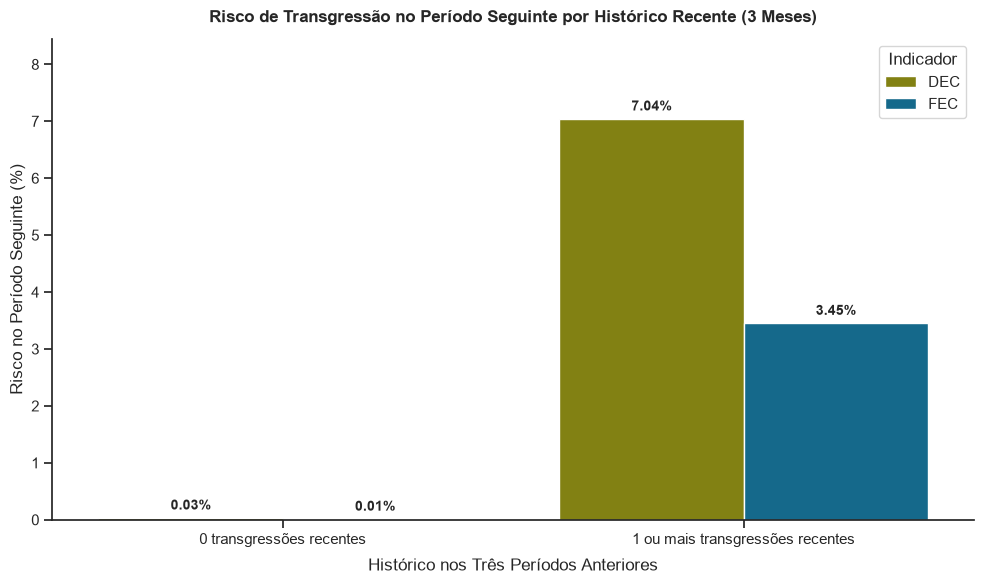

Gráfico salvo com sucesso em: ..\reports\figures\hypothesis_5_recent_history_risk.png


In [268]:
# Gráfico do risco no período seguinte por histórico recente

full_image_path = os.path.join(FIGURES_DIR, "hypothesis_5_recent_history_risk.png")
relative_image_path = os.path.relpath(full_image_path)

history_order = [
    "0 transgressões recentes",
    "1 ou mais transgressões recentes",
]
plot_hypothesis_5 = df_hypothesis_5.copy()
plot_hypothesis_5["faixa_historico_recente"] = pd.Categorical(
    plot_hypothesis_5["faixa_historico_recente"],
    categories=history_order,
    ordered=True,
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=plot_hypothesis_5,
    x="faixa_historico_recente",
    y="risco_periodo_seguinte",
    hue="SigIndicador",
    palette=colors[:2],
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=4,
        fontsize=10,
        fontweight="bold",
    )

plt.title("Risco de Transgressão no Período Seguinte por Histórico Recente (3 Meses)", fontweight="bold", pad=12)
plt.xlabel("Histórico nos Três Períodos Anteriores", labelpad=8)
plt.ylabel("Risco no Período Seguinte (%)")
plt.ylim(0, df_hypothesis_5["risco_periodo_seguinte"].max() * 1.20)
plt.legend(title="Indicador", loc="upper right", frameon=True)
sns.despine(top=True, right=True)

plt.tight_layout()
plt.savefig(relative_image_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Gráfico salvo com sucesso em: {relative_image_path}")

**Veredito**

>**Hipótese Confirmada!** O histórico recente (janela de 3 períodos) é um preditor direto e expressivo de risco de transgressão regulatória imediata tanto para o DEC quanto para o FEC.

- Para o DEC, a probabilidade de transgressão no período seguinte salta de `0,03%` (sem infrações recentes) para `7,04%` quando houve ao menos uma infração nos últimos 3 períodos, isto é, uma elevação de mais de `230 vezes` no risco. Para o FEC, o risco salta de `0,01%` para `3,45%`, um aumnto de `345 vezes`.

- Os conjuntos que cometeram transgressões recentes já operam com médias apuradas degradadas com `10,45` de DEC contra `1,15` no grupo estável. Já para FEC, há `3,05` interrupções contra `0,52`.

---

## 11. Síntese Exploratória

### 11.1. Resumo do Teste de Hipóteses

| Hipótese | Foco Analítico | Resultado | Evidência Principal |
| --- | --- | --- | --- |
| **H01:** Os conjuntos com histórico mais frequente de transgressões de DEC/FEC apresentam maior probabilidade de ultrapassar o limite no período seguinte | Persistência de falhas acumuladas | **Confirmada** | O risco de nova quebra de DEC salta de **0,03%** (sem histórico) para **21,43%** ($\ge 6$ infrações).|
| **H02:** As interrupções não programadas apresentam maior contribuição para o impacto operacional e para a variação do DEC do que interrupções programadas | Impacto Não Programada vs. Programada | **Confirmada** | Eventos acidentais concentram **94,5% do DEC** e **93,9% de consumidor-horas** ($>7,5\text{ bilhões}$).|
| **H03:** Determinados meses, regiões ou distribuidoras concentram níveis maiores de DEC, FEC ou ultrapassagens regulatórias | Concentração geográfica e temporal | **Confirmada** | **Centro-Oeste** atinge pico crítico nacional de transgressão de DEC em **outubro (0,95%)**.|
| **H04:**  Conjuntos com maior quantidade cadastral de unidades consumidoras apresentam menor tempo médio de interrupção | Relação do porte do conjunto com DEC | **Refutada** | Não há redução linear; conjuntos com $\ge 50.000$ unidades consumidoras dobram o DEC médio (**2,35 h**).|
| **H05:** O histórico recente de DEC/FEC e do volume de interrupções pode contribuir para prever o risco de transgressão regulatória no período seguinte | Inércia recente nos 3 meses anteriores | **Confirmada** | Ter $\ge 1$ violação recente eleva o risco subsequente de **0,03% para 7,04%** no DEC e de **0,01% para 3,45%** no FEC.|

### 11.2. Principais Insights

- A quebra de continuidade não ocorre de forma aleatória. O histórico atua como um multiplicador de risco (elevação de mais de **230 vezes** no DEC).

- Conjuntos que reincidem operam com patamares basais já degradados (média histórica de `10,45h` vs. `1,15h`).

- A operação programada é residual (`5,5% do DEC`). As falhas de materiais e equipamentos internos lideram o volume e a duração total no país, constituindo um passivo que não pode ser expurgado junto ao regulador.
 
- O pico de infrações concentra-se no início do período de chuvoso no Centro-Oeste (setembro a novembro, ápice em outubro com `0,95%`), enquanto regiões como o Sudeste sustentam índices controlados o ano inteiro.

- A soma cadastral de `NUCT*` revela que o ganho de escala só reduz o DEC até o porte intermediário (`0,92h`). Acima de 50 mil consumidores, a complexidade de alimentadores de grande porte duplica a duração média (`2,35h`).

- A refutação da Hipótese 04 e a assimetria extrema das transgressões demandam a adoção de modelos baseados em árvores (XGBoost, LightGBM ou CatBoost), capazes de mapear descontinuidades sem exigir linearidade dos parâmetros.